In [4]:
import polars as pl
import pathlib
from project_paths import paths, project_root


input_dir = project_root / "data" / "input"

anchor_files = [input_dir/"combined_data_2019-09-01.parquet", input_dir/"combined_data_2025-10-01.parquet"]


quarters = [file for file in input_dir.glob("combined_indicators_*.parquet")]

print([str(f) for f in anchor_files])
print([str(f) for f in quarters])

['C:\\Users\\Daniel\\projects\\imd_feature_engineering\\data\\input\\combined_data_2019-09-01.parquet', 'C:\\Users\\Daniel\\projects\\imd_feature_engineering\\data\\input\\combined_data_2025-10-01.parquet']
['C:\\Users\\Daniel\\projects\\imd_feature_engineering\\data\\input\\combined_indicators_2020-01-01.parquet', 'C:\\Users\\Daniel\\projects\\imd_feature_engineering\\data\\input\\combined_indicators_2020-04-01.parquet', 'C:\\Users\\Daniel\\projects\\imd_feature_engineering\\data\\input\\combined_indicators_2020-07-01.parquet', 'C:\\Users\\Daniel\\projects\\imd_feature_engineering\\data\\input\\combined_indicators_2020-10-01.parquet', 'C:\\Users\\Daniel\\projects\\imd_feature_engineering\\data\\input\\combined_indicators_2021-01-01.parquet', 'C:\\Users\\Daniel\\projects\\imd_feature_engineering\\data\\input\\combined_indicators_2021-04-01.parquet', 'C:\\Users\\Daniel\\projects\\imd_feature_engineering\\data\\input\\combined_indicators_2021-07-01.parquet', 'C:\\Users\\Daniel\\projects\

In [5]:
# i need to make the schema of every feature frame the same

all_files = anchor_files
all_files.extend(quarters)
all_dfs = [pl.read_parquet(file) for file in all_files]
all_schemas = [set(df.columns) for df in all_dfs]

all_columns = set()
common_columns = all_schemas[0]
for columns in all_schemas:
    # print(len(common_columns))
    # print(len(all_columns))
    common_columns = common_columns.intersection(columns)
    all_columns = all_columns.union(columns)

print(len(common_columns))
print(len(all_columns))

lost_columns = all_columns.difference(common_columns)

lost_columns

380
416


{'landuse_aquaculture_0',
 'landuse_basin_0',
 'landuse_basketball_0',
 'landuse_churchyard_0',
 'landuse_depot_0',
 'landuse_education_0',
 'landuse_field_0',
 'landuse_forest_0',
 'landuse_garden_0',
 'landuse_graveyard_0',
 'landuse_greenfield_0',
 'landuse_healthcare_0',
 'landuse_heathland_0',
 'landuse_highway_0',
 'landuse_landfill_0',
 'landuse_logistics_0',
 'landuse_paddock_0',
 'landuse_park_0',
 'landuse_pigeon_lofts_0',
 'landuse_pond_0',
 'landuse_private_0',
 'landuse_proposed_construction_0',
 'landuse_proposed_station_0',
 'landuse_quarry_0',
 'landuse_reservoir_0',
 'landuse_ret_0',
 'landuse_site_of-Old_Observatory_0',
 'landuse_terminal_0',
 'landuse_traffic_island_0',
 'landuse_village_green_0',
 'landuse_vineyard_0',
 'landuse_wasteland_0',
 'landuse_waterway_0',
 'landuse_wetland_0',
 'landuse_wood_0',
 'landuse_yes_0'}

In [6]:
bristol_only_dfs = [pl.read_parquet(f) for f in quarters]
bristol_schemas = [set(df.columns) for df in bristol_only_dfs]

bristol_all_columns = set()
bristol_common_columns = all_schemas[0]
for columns in bristol_schemas:
    bristol_common_columns = common_columns.intersection(columns)
    bristol_all_columns = all_columns.union(columns)

print(len(bristol_common_columns))
print(len(bristol_all_columns))

bristol_lost_columns = bristol_all_columns.difference(bristol_common_columns)

bristol_lost_columns

380
416


{'landuse_aquaculture_0',
 'landuse_basin_0',
 'landuse_basketball_0',
 'landuse_churchyard_0',
 'landuse_depot_0',
 'landuse_education_0',
 'landuse_field_0',
 'landuse_forest_0',
 'landuse_garden_0',
 'landuse_graveyard_0',
 'landuse_greenfield_0',
 'landuse_healthcare_0',
 'landuse_heathland_0',
 'landuse_highway_0',
 'landuse_landfill_0',
 'landuse_logistics_0',
 'landuse_paddock_0',
 'landuse_park_0',
 'landuse_pigeon_lofts_0',
 'landuse_pond_0',
 'landuse_private_0',
 'landuse_proposed_construction_0',
 'landuse_proposed_station_0',
 'landuse_quarry_0',
 'landuse_reservoir_0',
 'landuse_ret_0',
 'landuse_site_of-Old_Observatory_0',
 'landuse_terminal_0',
 'landuse_traffic_island_0',
 'landuse_village_green_0',
 'landuse_vineyard_0',
 'landuse_wasteland_0',
 'landuse_waterway_0',
 'landuse_wetland_0',
 'landuse_wood_0',
 'landuse_yes_0'}

since the only thing happening here is the date of the query is changing for the api call to overpass/osm, I think these features changing from being completely missing to not missing is due to data being added and removed to open street map, not the landuse actually changing over time. While something like "landuse_forest_0" would change if the forest was cleared and this could be interesting information, the ones here that are landuse_churchyard and landuse_waterway are, imo, unlikely to have actually changed. I think the safest thing to do is to remove all of these columns rather than fill them with 0 for quarters when its not present. Even if we included them, they are probably so sparse that they contain little useful information. 

In [7]:
anchor_dfs = {
    "2019": pl.read_parquet(input_dir/"combined_data_2019-09-01.parquet", columns=list(common_columns)),
    "2025": pl.read_parquet(input_dir/"combined_data_2025-10-01.parquet", columns=list(common_columns)),
}




In [8]:
common_columns

{'%_claims_nwr',
 '%_claims_planfw',
 '%_claims_prepfw',
 '%_claims_sfw',
 'Action to be taken by another organisation',
 'Awaiting court outcome',
 'Court result unavailable',
 'D_count_transactions',
 'D_mean_price',
 'F_count_transactions',
 'F_mean_price',
 'Formal action is not in the public interest',
 'Further action is not in the public interest',
 'Further investigation is not in the public interest',
 'Investigation complete; no suspect identified',
 'Local resolution',
 'O_count_transactions',
 'O_mean_price',
 'Offender given a caution',
 'Offender given a drugs possession warning',
 'S_count_transactions',
 'S_mean_price',
 'Status update unavailable',
 'Suspect charged as part of another case',
 'T_count_transactions',
 'T_mean_price',
 'Unable to prosecute suspect',
 'Under investigation',
 'aged_under_15',
 'anti-social-behaviour',
 'bicycle-theft',
 'burglary',
 'count_alcohol_gambling_0',
 'count_alcohol_gambling_1000',
 'count_alcohol_gambling_1250',
 'count_alcohol_

In [9]:
df_2019 = anchor_dfs.get("2019")

df_2019.select(
        pl.col("total_crimes"),
        pl.col("violent-crime"),
        pl.col("anti-social-behaviour"),
        pl.col("burglary"),
        pl.col("drugs"),
        pl.col("total_claims") ,
        pl.col("total_nwr_claims") ,
        pl.col("total_transactions"),
        pl.col("aged_under_15"), 
        pl.col("pension_age_population")
).describe()



statistic,total_crimes,violent-crime,anti-social-behaviour,burglary,drugs,total_claims,total_nwr_claims,total_transactions,aged_under_15,pension_age_population
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",1273.0,1273.0,1273.0,1273.0,1273.0,1273.0,1273.0,1273.0,1273.0,1273.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",186.148468,65.63315,0.0,12.746269,5.681854,425.229379,128.167321,28.326787,292.295365,290.945012
"""std""",302.687406,95.068759,0.0,13.712715,16.224403,462.240064,145.180671,17.072037,123.038059,139.698052
"""min""",7.0,2.0,0.0,0.0,0.0,0.0,0.0,2.0,9.0,9.0
"""25%""",71.0,24.0,0.0,5.0,1.0,129.0,33.0,18.0,215.0,195.0
"""50%""",117.0,45.0,0.0,9.0,2.0,281.0,85.0,25.0,281.0,276.0
"""75%""",190.0,74.0,0.0,16.0,5.0,549.0,165.0,34.0,356.0,370.0
"""max""",4133.0,1365.0,0.0,147.0,247.0,3175.0,1099.0,239.0,1158.0,1075.0


anti social behaviour is archived in a separate place by police uk, so it will never be available in the years that are fetched from the archive rather than the street level crime api. Fetching it from a separate location and combining it is a significant enough addition to the data pipeline, that at this point i think it is wisest to exclude it from being a potential feature. 

In [10]:
df_2019.select(
    pl.col("total_crimes"),
    pl.col("total_claims"),
).filter(
    pl.col("total_crimes").eq(0) | pl.col("total_claims").eq(0)
).height


15

In [11]:

anchor_dfs.get("2025").select(
    pl.col("total_crimes"),
    pl.col("total_claims"),
).filter(
    pl.col("total_crimes").eq(0) | pl.col("total_claims").eq(0)
).height

0

in this notebook, the engineered features will be slightly different from the ones used in the previous experiment (7_ridge_vs_slx experiment 2). Previously, we calculated rates for crimes and universal credit claims as per 1000 residents for all. However, these means that the population information is in every column. In order to try and reduce multicolinearity in these columns, we can calculate total crimes per pop and total claims per pop, then ratios of each type of crime to total crime and each type of claim to total claims. This should contain all the same information - encoding the total crimes/claims, the population, and the types of crimes/claims (there is no information loss - you could use the new total rate + ratios to reconstruct the rates of each subtype, which is what we are currently using). But producing them in this way should reduce the correlations between the different crimes and claims columns. It obviously separate the correlation of count of total crimes and count of subtype of crime, but the individual ratios are also plausibly less correlated since there are many degrees of freedom - we are not including all the crime subtypes. This should allow the learning algorithm to calculate more useful and interpretable coefficients for a linear model. 

This is safe to do because we know that total crimes and total claims is almost never 0 (although theoretically possible). Having checked, 2025 is complete free of 0s in these columns, and 2019 has just a few. In these cases, we will fill with 0 after creating the rate. This is defensible since it is a proxy for "there is no information in this column". We will still have the 0 value for total claims/crimes, which is actual signal. 

In [12]:
from pathlib import Path

def create_engineered_features(input_file: Path|pl.DataFrame):

    if type(input_file) is Path:
        raw = pl.read_parquet(input_file)
    elif type(input_file) is pl.DataFrame:
        raw = input_file
    else:
        raise TypeError

    engineered = raw.with_columns(
        (pl.col("total_crimes") / pl.col("lsoa_population") * 1000).alias("crime_rate_per_1000"),
        (pl.col("total_claims") / pl.col("working_age_population")).alias("uc_claim_rate"),
        (pl.col("total_transactions") / pl.col("lsoa_population") * 1000).alias("transactions_per_capita"),
        (pl.col("violent-crime") / pl.col("total_crimes")).alias("violent_crime_share"),
        (pl.col("anti-social-behaviour") / pl.col("total_crimes")).alias("asb_share"),
        (pl.col("burglary") / pl.col("total_crimes")).alias("burglary_share"),
        (pl.col("drugs") / pl.col("total_crimes")).alias("drugs_share"),
        (pl.col("total_nwr_claims") / pl.col("total_claims")).alias("uc_nwr_share"),
        (pl.col("aged_under_15") / pl.col("lsoa_population")).alias("youth_share"),
        (pl.col("pension_age_population") / pl.col("lsoa_population")).alias("elderly_share"),
    ).with_columns(
        pl.when(pl.col(c).is_nan() | pl.col(c).is_infinite())
        .then(0.0)
        .otherwise(pl.col(c))
        .alias(c)
        for c in [
            "violent_crime_share",
            "asb_share",
            "burglary_share",
            "drugs_share",
            "uc_nwr_share",
        ]
    )

    input_path = project_root / "data" / "input" / "combined_engineered_interpolate_experiment.parquet"
    engineered.write_parquet(input_path)

    return engineered

In [13]:
from imd_features.config import FeatureSetConfig, GroupConfig

medium_config = FeatureSetConfig(
    name="interpolation_modelling_medium",
    description="23 non spatial features, broader domain coverage, no buffers",
    groups={
        "index": GroupConfig(columns=["snapshot_date"]),
        "crime": GroupConfig(columns=[
            "crime_rate_per_1000",
            "violent_crime_share",
            "burglary_share",
            "drugs_share",
            "resolution_rate",
        ]),
        "uc": GroupConfig(columns=[
            "uc_claim_rate",
            "uc_nwr_share",
            "%_claims_planfw",
            "%_claims_sfw",
        ]),
        "land_registry": GroupConfig(columns=[
            "lsoa_mean_price",
            "lsoa_median_price",
            "lsoa_price_inequality",
            "transactions_per_capita",
            "flats_proportion",
            "terraced_proportion",
            "detached_proportion",
            "freehold_proportion",
        ]),
        "osm_landuse": GroupConfig(columns=[
            "landuse_residential_0",
            "landuse_industrial_0",
            "landuse_commercial_0",
            "streetlit_percentage",
        ]),
        "demographics": GroupConfig(columns=[
            "youth_share",
            "elderly_share",
        ]),
    },
)

In [14]:
from imd_features.process import create_feature_set

combined_anchor_df = pl.concat(
    [
        anchor_dfs.get("2019").with_columns(pl.lit("2019-09-01").alias("snapshot_date")),
        anchor_dfs.get("2025").with_columns(pl.lit("2025-10-01").alias("snapshot_date")),
    ],
    how="diagonal_relaxed"
)
engineered_df = create_engineered_features(combined_anchor_df)
file_path = project_root / "data" / "input" / "combined_engineered_interpolate_experiment.parquet"
features_df, *_ = create_feature_set(file_path, config=medium_config)


In [15]:
features_df.describe()

statistic,lsoa_code,snapshot_date,crime_rate_per_1000,violent_crime_share,burglary_share,drugs_share,resolution_rate,uc_claim_rate,uc_nwr_share,%_claims_planfw,%_claims_sfw,lsoa_mean_price,lsoa_median_price,lsoa_price_inequality,transactions_per_capita,flats_proportion,terraced_proportion,detached_proportion,freehold_proportion,landuse_residential_0,landuse_industrial_0,landuse_commercial_0,streetlit_percentage,youth_share,elderly_share
str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""2546""","""2546""",2546.0,2546.0,2546.0,2546.0,2546.0,2546.0,2546.0,2546.0,2546.0,2546.0,2546.0,2546.0,2546.0,2546.0,2546.0,2546.0,2546.0,2546.0,2546.0,2546.0,2546.0,2546.0,2546.0
"""null_count""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",null,null,97.973723,0.40328,0.075843,0.02747,0.423999,0.980763,0.454373,0.011675,0.476323,312936.649718,256102.19835,4.062774,14.673375,0.211536,0.320135,0.147531,0.667701,0.433367,0.020383,0.013006,0.148269,0.169403,0.176722
"""std""",null,null,126.827679,0.127048,0.065369,0.027634,0.141515,1.07611,0.220019,0.019608,0.235483,337889.877047,133606.17716,30.374979,7.446801,0.244899,0.249998,0.208554,0.281959,0.341758,0.065383,0.044449,0.184548,0.055611,0.090425
"""min""","""E01007823""","""2019-09-01""",5.010737,0.035088,0.0,0.0,0.034483,0.0,0.0,0.0,0.0,56937.5,39875.0,1.0,0.454752,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.003763,0.002572
"""25%""",null,null,42.480884,0.31746,0.033755,0.008065,0.326087,0.226903,0.289941,0.0,0.268128,181304.347826,165000.0,1.75,10.00435,0.0,0.111111,0.0,0.461538,0.066624,0.0,0.0,0.0,0.141706,0.113095
"""50%""",null,null,68.762279,0.408728,0.058824,0.021277,0.430233,0.568053,0.477667,0.0,0.451604,258869.565217,240000.0,2.21875,13.967926,0.121212,0.28,0.052632,0.733333,0.433019,0.0,0.0,0.078322,0.172231,0.164887
"""75%""",null,null,109.511568,0.489796,0.097983,0.039604,0.528634,1.333942,0.65099,0.018735,0.638112,351268.214286,315000.0,2.97732,18.134715,0.307692,0.5,0.214286,0.909091,0.722861,0.0,0.000052,0.222035,0.204313,0.234364
"""max""","""E01035623""","""2025-10-01""",1950.641026,0.83871,0.614458,0.346939,0.85,10.419241,1.0,0.148315,1.0,7.3253e6,2.525e6,1363.636364,91.887735,1.0,1.0,1.0,1.0,1.591956,0.581432,0.809367,0.948287,0.374101,0.58587


In [16]:
df_targets_2019 = pl.read_parquet(project_root / "data" / "input" / "2019_imd_target.parquet")
df_targets_2025 = pl.read_parquet(project_root / "data" / "input" / "2025_imd_target.parquet")

In [17]:
def prepare_target_raw_score(
    targets_2019: pl.DataFrame,
    targets_2025: pl.DataFrame,
) -> pl.DataFrame:
    return pl.concat([
        targets_2019.select(
            pl.col("lsoa_code_2011").alias("lsoa_code"), # has already been translated to 2021 codes, but not renamed 
            pl.col("score").alias("target"),
        ).with_columns(
            pl.lit("2019-09-01").alias("snapshot_date")
        ),
        targets_2025.select(
            "lsoa_code", 
            pl.col("score").alias("target"),
        ).with_columns(
            pl.lit("2025-10-01").alias("snapshot_date")
        ),
    ])


def prepare_target_log_score(
    targets_2019: pl.DataFrame,
    targets_2025: pl.DataFrame,
) -> pl.DataFrame:
    return pl.concat([
        targets_2019.select(
            pl.col("lsoa_code_2011").alias("lsoa_code"), # has already been translated to 2021 codes, but not renamed
            pl.col("score").log1p().alias("target")
        ).with_columns(
            pl.lit("2019-09-01").alias("snapshot_date")
        ),
        targets_2025.select(
            "lsoa_code", 
            pl.col("score").log1p().alias("target")
        ).with_columns(
            pl.lit("2025-10-01").alias("snapshot_date")
        ),
    ])


def prepare_target_nat_rank(
    targets_2019: pl.DataFrame,
    targets_2025: pl.DataFrame,
) -> pl.DataFrame:
    return pl.concat([
        targets_2019.select(
            pl.col("lsoa_code_2011").alias("lsoa_code"), # has already been translated to 2021 codes, but not renamed
            pl.col("rank").alias("target")
        ).with_columns(
            pl.lit("2019-09-01").alias("snapshot_date")
        ),
        targets_2025.select(
            "lsoa_code", 
            pl.col("rank").alias("target")
        ).with_columns(
            pl.lit("2025-10-01").alias("snapshot_date")
        ),
    ])



In [18]:
df_tgt_raw_scores = prepare_target_raw_score(targets_2019=df_targets_2019, targets_2025=df_targets_2025)
df_tgt_scaled_scores = prepare_target_log_score(targets_2019=df_targets_2019, targets_2025=df_targets_2025)
df_tgt_ranks = prepare_target_nat_rank(targets_2019=df_targets_2019, targets_2025=df_targets_2025)

In [19]:
df_tgt_raw_scores.describe()
# df_tgt_scaled_scores.describe()

statistic,lsoa_code,target,snapshot_date
str,str,f64,str
"""count""","""70115""",70115.0,"""70115"""
"""null_count""","""0""",0.0,"""0"""
"""mean""",null,21.623319,null
"""std""",null,15.406582,null
"""min""","""E01000001""",0.165,"""2019-09-01"""
"""25%""",null,9.9,null
"""50%""",null,17.523,null
"""75%""",null,29.445,null
"""max""","""E01035762""",94.223,"""2025-10-01"""


In [20]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr
import numpy as np

alphas = [0.01, 0.1, 1, 10, 100, 1000]
feature_columns = [column for column in features_df.columns if column not in ("lsoa_code", "snapshot_date")]


def temporal_holdout(features: pl.DataFrame, targets: pl.DataFrame, label: str):
    data = features.join(targets, on=["lsoa_code", "snapshot_date"], how="inner")

    train_2019 = data.filter(pl.col("snapshot_date") == "2019-09-01")
    test_2025 = data.filter(pl.col("snapshot_date") == "2025-10-01")
    train_2025 = test_2025
    test_2019 = train_2019

    results = []
    for alpha in alphas:
        for train, test, direction in [
            (train_2019, test_2025, "2019 -> 2025"),
            (train_2025, test_2019, "2025 -> 2019"),
        ]:
            X_train = train.select(feature_columns).to_numpy()
            y_train = train.select("target").to_numpy().ravel()
            X_test = test.select(feature_columns).to_numpy()
            y_test = test.select("target").to_numpy().ravel()

            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)

            model = Ridge(alpha=alpha)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            results.append({
                "target": label,
                "direction": direction,
                "alpha": alpha,
                "spearman": spearmanr(y_test, y_pred).statistic,
                "r2": model.score(X_test, y_test),
            })

    return pl.DataFrame(results)


results = pl.concat([
    temporal_holdout(features_df, df_tgt_raw_scores, "raw_score"),
    temporal_holdout(features_df, df_tgt_scaled_scores, "log_score"),
    temporal_holdout(features_df, df_tgt_ranks, "national_rank"),
])



results

target,direction,alpha,spearman,r2
str,str,f64,f64,f64
"""raw_score""","""2019 -> 2025""",0.01,0.94123,-2.335624
"""raw_score""","""2025 -> 2019""",0.01,0.764603,-0.51314
"""raw_score""","""2019 -> 2025""",0.1,0.941231,-2.334946
"""raw_score""","""2025 -> 2019""",0.1,0.764765,-0.512796
"""raw_score""","""2019 -> 2025""",1.0,0.941231,-2.328182
…,…,…,…,…
"""national_rank""","""2025 -> 2019""",10.0,0.717625,-0.424751
"""national_rank""","""2019 -> 2025""",100.0,0.94168,-0.89942
"""national_rank""","""2025 -> 2019""",100.0,0.750865,-0.237561


In [21]:

with pl.Config(tbl_cols=5, tbl_rows=200):
    print(results)

shape: (36, 5)
┌───────────────┬──────────────┬────────┬──────────┬───────────┐
│ target        ┆ direction    ┆ alpha  ┆ spearman ┆ r2        │
│ ---           ┆ ---          ┆ ---    ┆ ---      ┆ ---       │
│ str           ┆ str          ┆ f64    ┆ f64      ┆ f64       │
╞═══════════════╪══════════════╪════════╪══════════╪═══════════╡
│ raw_score     ┆ 2019 -> 2025 ┆ 0.01   ┆ 0.94123  ┆ -2.335624 │
│ raw_score     ┆ 2025 -> 2019 ┆ 0.01   ┆ 0.764603 ┆ -0.51314  │
│ raw_score     ┆ 2019 -> 2025 ┆ 0.1    ┆ 0.941231 ┆ -2.334946 │
│ raw_score     ┆ 2025 -> 2019 ┆ 0.1    ┆ 0.764765 ┆ -0.512796 │
│ raw_score     ┆ 2019 -> 2025 ┆ 1.0    ┆ 0.941231 ┆ -2.328182 │
│ raw_score     ┆ 2025 -> 2019 ┆ 1.0    ┆ 0.766146 ┆ -0.509381 │
│ raw_score     ┆ 2019 -> 2025 ┆ 10.0   ┆ 0.941294 ┆ -2.2621   │
│ raw_score     ┆ 2025 -> 2019 ┆ 10.0   ┆ 0.777696 ┆ -0.476966 │
│ raw_score     ┆ 2019 -> 2025 ┆ 100.0  ┆ 0.942056 ┆ -1.725229 │
│ raw_score     ┆ 2025 -> 2019 ┆ 100.0  ┆ 0.816059 ┆ -0.266938 │
│ raw_scor

2019 features are good at predicting 2025 values, but 2025 are not as good at predicting 2019. This is a replication of a result already in the existing "across snapshots" notebook, but is holding. It holds across all the target types and across the entire alpha sweep. This way round is actually okay for our project. We will have to explain that our results become more trustworthy as they get more recent, but since 2019 training data will always be included, hopefully the model will be good enough to predict 2020 or 2021 as well.

The r2 here shows that the readings are often completely wrong. This will be because the model is learning the scale of one of the timeframes and applying it to the other. The spearman score shows that the order has still been learned properly.  

This was expected for the raw scores, but I had hoped that the scaling or the use of national rank would fix this. Actually, on reflection (long time since i started this notebook with the pipeline debugging...) the log transformation was only for the slight positive skew in the distribution of scores. 

Next, ill add scaling and centring using the mean and standard deviation. Each timeframe will be transformed then concatinated so that its mean is centred on 0 and an std is a consistant distance from this. This should mean that both timeframes end up forming one consistant scale that the model can make predictions in

The failure of nat rank to produces a sensible r2 score could be because using national rankings makes it far too sensitive to small changes in the methodology. For example, Bristol as a whole may have jumped 1000 places in the rankings. Then, the abs error of each lsoa in the model is going to be huge, even if the ranking is perfect. 


In [22]:
def prepare_target_zscore(
    targets_2019: pl.DataFrame,
    targets_2025: pl.DataFrame,
) -> pl.DataFrame:
    mean_2019, std_2019 = targets_2019["score"].mean(), targets_2019["score"].std()
    mean_2025, std_2025 = targets_2025["score"].mean(), targets_2025["score"].std()

    return pl.concat([
        targets_2019.select(
            pl.col("lsoa_code_2011").alias("lsoa_code"), # has already been translated to 2021 codes, but not renamed
            ((pl.col("score") - mean_2019) / std_2019).alias("target"),
        ).with_columns(pl.lit("2019-09-01").alias("snapshot_date")),
        targets_2025.select(
            "lsoa_code",
            ((pl.col("score") - mean_2025) / std_2025).alias("target"),
        ).with_columns(pl.lit("2025-10-01").alias("snapshot_date")),
    ])


def prepare_target_log_zscore(
    targets_2019: pl.DataFrame,
    targets_2025: pl.DataFrame,
) -> pl.DataFrame:
    log_2019 = targets_2019.with_columns(pl.col("score").log1p().alias("log_score"))
    log_2025 = targets_2025.with_columns(pl.col("score").log1p().alias("log_score"))

    mean_2019, std_2019 = log_2019["log_score"].mean(), log_2019["log_score"].std()
    mean_2025, std_2025 = log_2025["log_score"].mean(), log_2025["log_score"].std()

    return pl.concat([
        log_2019.select(
            pl.col("lsoa_code_2011").alias("lsoa_code"), # has already been translated to 2021 codes, but not renamed
            ((pl.col("log_score") - mean_2019) / std_2019).alias("target"),
        ).with_columns(pl.lit("2019-09-01").alias("snapshot_date")),
        log_2025.select(
            "lsoa_code",
            ((pl.col("log_score") - mean_2025) / std_2025).alias("target"),
        ).with_columns(pl.lit("2025-10-01").alias("snapshot_date")),
    ])

In [23]:
df_tgt_zscore_scores = prepare_target_zscore(df_targets_2019, df_targets_2025)
df_tgt_zscore_log_scores = prepare_target_log_zscore(df_targets_2019, df_targets_2025)

more_results = pl.concat([
    temporal_holdout(features_df, df_tgt_zscore_scores, "scaled with zscore"),
    temporal_holdout(features_df, df_tgt_zscore_log_scores, "scaled with zscore + log transform"),
])


more_results

target,direction,alpha,spearman,r2
str,str,f64,f64,f64
"""scaled with zscore""","""2019 -> 2025""",0.01,0.94123,-2.675002
"""scaled with zscore""","""2025 -> 2019""",0.01,0.764603,-0.479669
"""scaled with zscore""","""2019 -> 2025""",0.1,0.941231,-2.674261
"""scaled with zscore""","""2025 -> 2019""",0.1,0.764765,-0.479341
"""scaled with zscore""","""2019 -> 2025""",1.0,0.941231,-2.666865
…,…,…,…,…
"""scaled with zscore + log trans…","""2025 -> 2019""",10.0,0.669108,-0.893585
"""scaled with zscore + log trans…","""2019 -> 2025""",100.0,0.943933,-1.078122
"""scaled with zscore + log trans…","""2025 -> 2019""",100.0,0.721479,-0.634294


In [24]:
with pl.Config(tbl_cols=5, tbl_rows=200):
    print(more_results)

shape: (24, 5)
┌─────────────────────────────────┬──────────────┬────────┬──────────┬───────────┐
│ target                          ┆ direction    ┆ alpha  ┆ spearman ┆ r2        │
│ ---                             ┆ ---          ┆ ---    ┆ ---      ┆ ---       │
│ str                             ┆ str          ┆ f64    ┆ f64      ┆ f64       │
╞═════════════════════════════════╪══════════════╪════════╪══════════╪═══════════╡
│ scaled with zscore              ┆ 2019 -> 2025 ┆ 0.01   ┆ 0.94123  ┆ -2.675002 │
│ scaled with zscore              ┆ 2025 -> 2019 ┆ 0.01   ┆ 0.764603 ┆ -0.479669 │
│ scaled with zscore              ┆ 2019 -> 2025 ┆ 0.1    ┆ 0.941231 ┆ -2.674261 │
│ scaled with zscore              ┆ 2025 -> 2019 ┆ 0.1    ┆ 0.764765 ┆ -0.479341 │
│ scaled with zscore              ┆ 2019 -> 2025 ┆ 1.0    ┆ 0.941231 ┆ -2.666865 │
│ scaled with zscore              ┆ 2025 -> 2019 ┆ 1.0    ┆ 0.766146 ┆ -0.476076 │
│ scaled with zscore              ┆ 2019 -> 2025 ┆ 10.0   ┆ 0.941294 ┆ -

results are kinda the same. Still some very good spearmans scores but failing r2s. 

Thinking about this more, this may just be inevitable in the specific test im doing. Im testing one timeframes ability to predict the other. so im training the model in the space of one year, with its scale and distribution of scores, then asking it to make predictions. The predictions will be in the same space it was trained in, but then im testing these predictions by comparing them to a different space. 

Even with this structural issue, i really expected the z score transformation to work. It ought to bring the two spaces together, with both being centred on 0 and the distributions being a similar shape. The spearman score is exactly the same between the raw and z score transformed input, meaning ( i think) that exactly the same predictions have been made (in the same order), but the r2 is actually slightly worse. It ought to improve if the scale of the two scores has been brought closer together. 

I think the clue might be that the raw ranking is also failing on r2, and i have hypothesised that this is because it is the national rank and could improve with a local rank. The same could be said for the score scaling. We should use the mean and std of the local lsoas (as in ones used in the model) not the mean and std of all uk lsoas. 

The lsoas in our dataset are not nationally representative of the UK, in fact we deliberately chose them all to be similar to bristol, a south west non capital city. 



In [25]:
training_lsoas = features_df.select("lsoa_code").unique()
df_targets_2019 = df_targets_2019.join(training_lsoas, left_on="lsoa_code_2011", right_on="lsoa_code", how="inner")
df_targets_2025 = df_targets_2025.join(training_lsoas, on="lsoa_code", how="inner")

In [26]:
def prepare_target_local_rank(
    targets_2019: pl.DataFrame,
    targets_2025: pl.DataFrame,
) -> pl.DataFrame:
    return pl.concat([
        targets_2019.select(
            pl.col("lsoa_code_2011").alias("lsoa_code"), # has already been translated to 2021 codes, but not renamed
            pl.col("score").rank().alias("target"),
        ).with_columns(pl.lit("2019-09-01").alias("snapshot_date")),
        targets_2025.select(
            "lsoa_code",
            pl.col("score").rank().alias("target"),
        ).with_columns(pl.lit("2025-10-01").alias("snapshot_date")),
    ])

In [27]:
df_tgt_raw_scores = prepare_target_raw_score(df_targets_2019, df_targets_2025)
df_tgt_scaled_scores = prepare_target_log_score(df_targets_2019, df_targets_2025)
df_tgt_zscore_scores = prepare_target_zscore(df_targets_2019, df_targets_2025)
df_tgt_zscore_log_scores = prepare_target_log_zscore(df_targets_2019, df_targets_2025)
df_tgt_ranks = prepare_target_local_rank(df_targets_2019, df_targets_2025)



even_more_results = pl.concat([
    temporal_holdout(features_df, df_tgt_raw_scores, "local filter - raw_score"),
    temporal_holdout(features_df, df_tgt_scaled_scores, "local filter - log_score"),
    temporal_holdout(features_df, df_tgt_ranks, "local filter - rank"),
    temporal_holdout(features_df, df_tgt_zscore_scores, "local filter - scaled with zscore"),
    temporal_holdout(features_df, df_tgt_zscore_log_scores, "local filter - scaled with zscore + log transform"),
])

even_more_results

target,direction,alpha,spearman,r2
str,str,f64,f64,f64
"""local filter - raw_score""","""2019 -> 2025""",0.01,0.94123,-2.335624
"""local filter - raw_score""","""2025 -> 2019""",0.01,0.764603,-0.51314
"""local filter - raw_score""","""2019 -> 2025""",0.1,0.941231,-2.334946
"""local filter - raw_score""","""2025 -> 2019""",0.1,0.764765,-0.512796
"""local filter - raw_score""","""2019 -> 2025""",1.0,0.941231,-2.328182
…,…,…,…,…
"""local filter - scaled with zsc…","""2025 -> 2019""",10.0,0.669108,-0.565596
"""local filter - scaled with zsc…","""2019 -> 2025""",100.0,0.943933,-0.93795
"""local filter - scaled with zsc…","""2025 -> 2019""",100.0,0.721479,-0.339009


In [28]:
with pl.Config(tbl_cols=5, tbl_rows=200):
    print(even_more_results)

shape: (60, 5)
┌─────────────────────────────────┬──────────────┬────────┬──────────┬───────────┐
│ target                          ┆ direction    ┆ alpha  ┆ spearman ┆ r2        │
│ ---                             ┆ ---          ┆ ---    ┆ ---      ┆ ---       │
│ str                             ┆ str          ┆ f64    ┆ f64      ┆ f64       │
╞═════════════════════════════════╪══════════════╪════════╪══════════╪═══════════╡
│ local filter - raw_score        ┆ 2019 -> 2025 ┆ 0.01   ┆ 0.94123  ┆ -2.335624 │
│ local filter - raw_score        ┆ 2025 -> 2019 ┆ 0.01   ┆ 0.764603 ┆ -0.51314  │
│ local filter - raw_score        ┆ 2019 -> 2025 ┆ 0.1    ┆ 0.941231 ┆ -2.334946 │
│ local filter - raw_score        ┆ 2025 -> 2019 ┆ 0.1    ┆ 0.764765 ┆ -0.512796 │
│ local filter - raw_score        ┆ 2019 -> 2025 ┆ 1.0    ┆ 0.941231 ┆ -2.328182 │
│ local filter - raw_score        ┆ 2025 -> 2019 ┆ 1.0    ┆ 0.766146 ┆ -0.509381 │
│ local filter - raw_score        ┆ 2019 -> 2025 ┆ 10.0   ┆ 0.941294 ┆ -

firstly, the r2 scores are still telling us that its meaningless to compare across. This is annoying but i think we have to move on.

The Spearman is 0.94, meaning the model gets the ordering almost perfect. If the ordering is that good, a simple linear transformation of the predictions (shift and scale) SHOULD produce near perfect r2 (expect high 0.9s, consistant with previous notebooks). 

I was hoping that I could figure out that transformation and apply it to the features and targets going into the modelling. I've clearly not hit upon the right one. The problem is that the model cant learn that transformation because it never sees the test year during training. Once we use both years in conjunction to produce the production model, this problem ought to resolve.


as i reread what i just typed, i think one issue could be scaling of the features. I typed that I scaled the features and targets going into modelling, but thats not true. I deliberately left the features unscaled originally and scaled them inside teh loop inside the temporal holdout function. 

At this point we will move onto combining the two anchors and train a single model. We have learned from this that there is some risk of the model drifting over time. While it should be safe to combine the data for 2019 and 2025 and interpolate between them, there is a danger that the model will drift and not perform as well once it is asked to extrapolate into future years. Theres no way of knowing (right now) how much of this is due to actual model drift and how much is because of the methodology change between reports. The latter actually strengthens the case for the production model because you can now have one know methodology that is repeatable and reusable in different time frames. 

Overall, this was a success. I did this test to double check that the model would be able to predict rankings across timeframes. Rankings was what ONS said would be usable across the two reports, and is actually the much more interpretable metric compared to score, and also is what we can visualize/present. This has been demonstrated with the >0.94 spearmans

In [29]:
features_df

lsoa_code,snapshot_date,crime_rate_per_1000,violent_crime_share,burglary_share,drugs_share,resolution_rate,uc_claim_rate,uc_nwr_share,%_claims_planfw,%_claims_sfw,lsoa_mean_price,lsoa_median_price,lsoa_price_inequality,transactions_per_capita,flats_proportion,terraced_proportion,detached_proportion,freehold_proportion,landuse_residential_0,landuse_industrial_0,landuse_commercial_0,streetlit_percentage,youth_share,elderly_share
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""E01015437""","""2019-09-01""",33.386328,0.428571,0.095238,0.0,0.428571,0.200855,0.170213,0.0,0.829787,297036.5,307500.0,3.072526,20.667727,0.076923,0.115385,0.576923,0.884615,1.0,0.0,0.0,0.0,0.174086,0.267886
"""E01015373""","""2019-09-01""",94.339623,0.44,0.045714,0.011429,0.462857,0.424837,0.406838,0.0,0.502564,228325.0,208475.0,2.461538,20.485175,0.368421,0.052632,0.394737,0.631579,0.983674,0.0,0.0,0.0,0.177898,0.079784
"""E01015412""","""2019-09-01""",18.136851,0.636364,0.0,0.0,0.318182,0.121257,0.0,0.0,1.0,380307.692308,385000.0,1.610169,10.71723,0.0,0.0,0.846154,1.0,0.190913,0.0,0.0,0.0,0.153339,0.29596
"""E01015360""","""2019-09-01""",41.97901,0.369048,0.166667,0.059524,0.559524,0.112787,0.110465,0.0,0.889535,369234.615385,383500.0,3.040541,12.993503,0.269231,0.0,0.692308,0.769231,0.619312,0.0,0.0,0.0,0.121939,0.115942
"""E01015300""","""2019-09-01""",32.724984,0.576923,0.057692,0.057692,0.596154,0.196739,0.458564,0.0,0.541436,424669.607143,481250.0,2.921053,17.621145,0.214286,0.0,0.75,0.714286,0.894073,0.0,0.0,0.0,0.164254,0.256765
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""E01008123""","""2025-10-01""",106.918239,0.508021,0.069519,0.016043,0.534759,3.314532,0.678685,0.031439,0.23392,153952.714286,132000.0,2.128713,4.002287,0.0,0.428571,0.0,1.0,0.0,0.0,0.0,0.0,0.271584,0.13036
"""E01007892""","""2025-10-01""",63.731932,0.494845,0.010309,0.092784,0.546392,3.71532,0.766234,0.01526,0.160065,149045.454545,152000.0,1.5,7.227332,0.181818,0.363636,0.0,0.818182,0.0,0.0,0.0,0.0,0.204336,0.250986
"""E01008022""","""2025-10-01""",159.735974,0.495868,0.041322,0.041322,0.528926,4.818182,0.694174,0.009123,0.24632,109500.0,102500.0,2.285714,3.30033,0.2,0.8,0.0,0.8,0.0,0.0,0.025667,0.0,0.186799,0.152475


In [30]:
from imd_features.cross_validate import cross_validate
from imd_features.spatial_utils import fetch_spatial_support_data
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from project_paths import paths

alphas = np.logspace(-2, 3, 100) # much finer grid than in previous nbs

target_z = prepare_target_zscore(df_targets_2019, df_targets_2025)
pooled = features_df.join(target_z, on=["lsoa_code", "snapshot_date"], how="inner")

feature_cols = [c for c in features_df.columns if c not in ("lsoa_code", "snapshot_date")]
X = pooled.select(feature_cols).to_numpy()
X = StandardScaler().fit_transform(X)
y = pooled.select("target").to_numpy().ravel()
lsoa_codes = pooled.select("lsoa_code").to_numpy().ravel()

_, groups_k, _ = fetch_spatial_support_data(
        lsoa_codes=pooled.select("lsoa_code").to_series().to_list(),
        boundaries_path=paths.polygons,
        lookup_path=paths.lads,
        n_clusters_per_city=8,
    )

results = []
for alpha in alphas:
    result = cross_validate(X, y, model=Ridge(alpha=alpha), cv_splitter=GroupKFold(n_splits=5), groups=groups_k)
    result["alpha"] = alpha
    results.append(result)

In [31]:
results

[{'r2_mean': 0.6499529932597247,
  'r2_std': 0.09922510657762859,
  'r2_per_fold': [0.7720236045890323,
   0.7208696846319884,
   0.6916282747004036,
   0.5289065746840358,
   0.5363368276931633],
  'rmse_mean': 0.5698014768785052,
  'rmse_std': 0.034880704750741516,
  'rmse_per_fold': [np.float64(0.5244645488345168),
   np.float64(0.5324537648123837),
   np.float64(0.5827260205505654),
   np.float64(0.6087281176053281),
   np.float64(0.6006349325897318)],
  'spearman_mean': 0.8215397064473111,
  'spearman_std': 0.0438875068040323,
  'spearman_per_fold': [np.float64(0.8305373830681811),
   np.float64(0.857549040709289),
   np.float64(0.8771722785856297),
   np.float64(0.7780679077354576),
   np.float64(0.7643719221379978)],
  'alpha': np.float64(0.01)},
 {'r2_mean': 0.6499531541069591,
  'r2_std': 0.09922499794658096,
  'r2_per_fold': [0.7720236433498273,
   0.7208696803877941,
   0.6916284799871547,
   0.5289069450498322,
   0.536337021760187],
  'rmse_mean': 0.5698013569814443,
  'rm

In [32]:
results_df = pl.DataFrame(results)

with pl.Config(tbl_cols=50, tbl_rows=200):
    print(results_df)

shape: (100, 10)
┌─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬────────┐
│ r2_mean ┆ r2_std  ┆ r2_per_ ┆ rmse_me ┆ rmse_st ┆ rmse_pe ┆ spearma ┆ spearma ┆ spearma ┆ alpha  │
│ ---     ┆ ---     ┆ fold    ┆ an      ┆ d       ┆ r_fold  ┆ n_mean  ┆ n_std   ┆ n_per_f ┆ ---    │
│ f64     ┆ f64     ┆ ---     ┆ ---     ┆ ---     ┆ ---     ┆ ---     ┆ ---     ┆ old     ┆ f64    │
│         ┆         ┆ list[f6 ┆ f64     ┆ f64     ┆ list[f6 ┆ f64     ┆ f64     ┆ ---     ┆        │
│         ┆         ┆ 4]      ┆         ┆         ┆ 4]      ┆         ┆         ┆ list[f6 ┆        │
│         ┆         ┆         ┆         ┆         ┆         ┆         ┆         ┆ 4]      ┆        │
╞═════════╪═════════╪═════════╪═════════╪═════════╪═════════╪═════════╪═════════╪═════════╪════════╡
│ 0.64995 ┆ 0.09922 ┆ [0.7720 ┆ 0.56980 ┆ 0.03488 ┆ [0.5244 ┆ 0.82154 ┆ 0.04388 ┆ [0.8305 ┆ 0.01   │
│ 3       ┆ 5       ┆ 24, 0.7 ┆ 1       ┆ 1       ┆ 65, 0.5 ┆         ┆ 8 

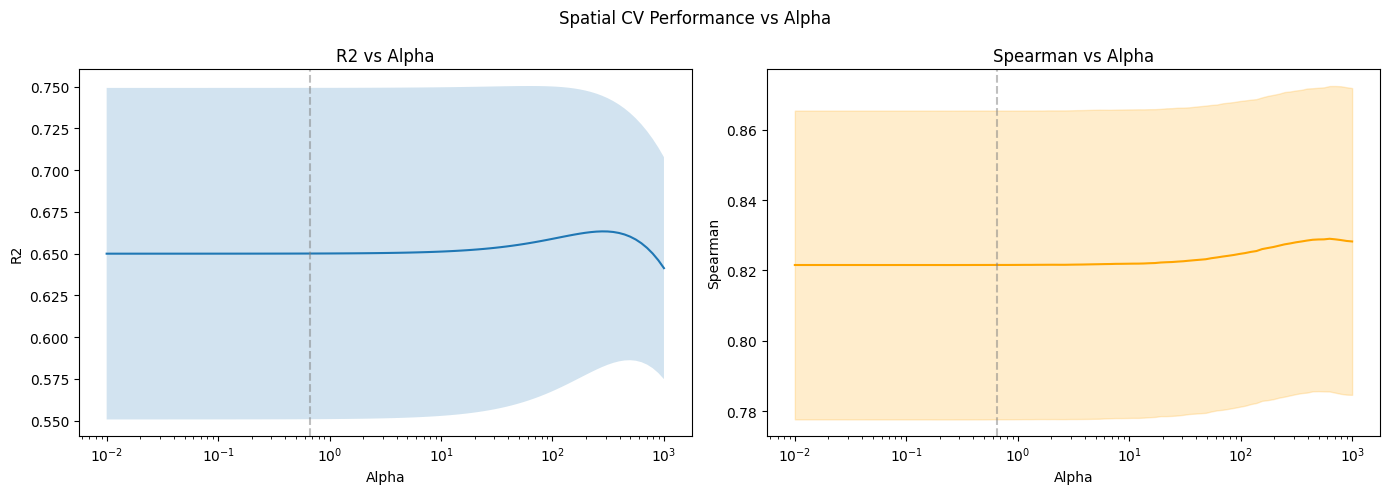

Best R2 alpha: 278.2559, R2: 0.6633 ± 0.0812, Spearman: 0.8277
Best Spearman alpha: 628.0291, R2: 0.6562, Spearman: 0.8290


In [33]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(results_df["alpha"], results_df["r2_mean"], label="R2")
axes[0].fill_between(
    results_df["alpha"],
    results_df["r2_mean"] - results_df["r2_std"],
    results_df["r2_mean"] + results_df["r2_std"],
    alpha=0.2,
)
axes[0].set_xscale("log")
axes[0].set_xlabel("Alpha")
axes[0].set_ylabel("R2")
axes[0].set_title("R2 vs Alpha")
axes[0].axvline(results_df.row(results_df["r2_mean"].arg_max())[0], color="grey", linestyle="--", alpha=0.5)

axes[1].plot(results_df["alpha"], results_df["spearman_mean"], label="Spearman", color="orange")
axes[1].fill_between(
    results_df["alpha"],
    results_df["spearman_mean"] - results_df["spearman_std"],
    results_df["spearman_mean"] + results_df["spearman_std"],
    alpha=0.2,
    color="orange",
)
axes[1].set_xscale("log")
axes[1].set_xlabel("Alpha")
axes[1].set_ylabel("Spearman")
axes[1].set_title("Spearman vs Alpha")
axes[1].axvline(results_df.row(results_df["spearman_mean"].arg_max())[0], color="grey", linestyle="--", alpha=0.5)

fig.suptitle("Spatial CV Performance vs Alpha")
fig.tight_layout()
plt.show()

best_row = results_df.row(results_df["r2_mean"].arg_max(), named=True)
print(f"Best R2 alpha: {best_row['alpha']:.4f}, R2: {best_row['r2_mean']:.4f} ± {best_row['r2_std']:.4f}, Spearman: {best_row['spearman_mean']:.4f}")

best_spearman = results_df.row(results_df["spearman_mean"].arg_max(), named=True)
print(f"Best Spearman alpha: {best_spearman['alpha']:.4f}, R2: {best_spearman['r2_mean']:.4f}, Spearman: {best_spearman['spearman_mean']:.4f}")

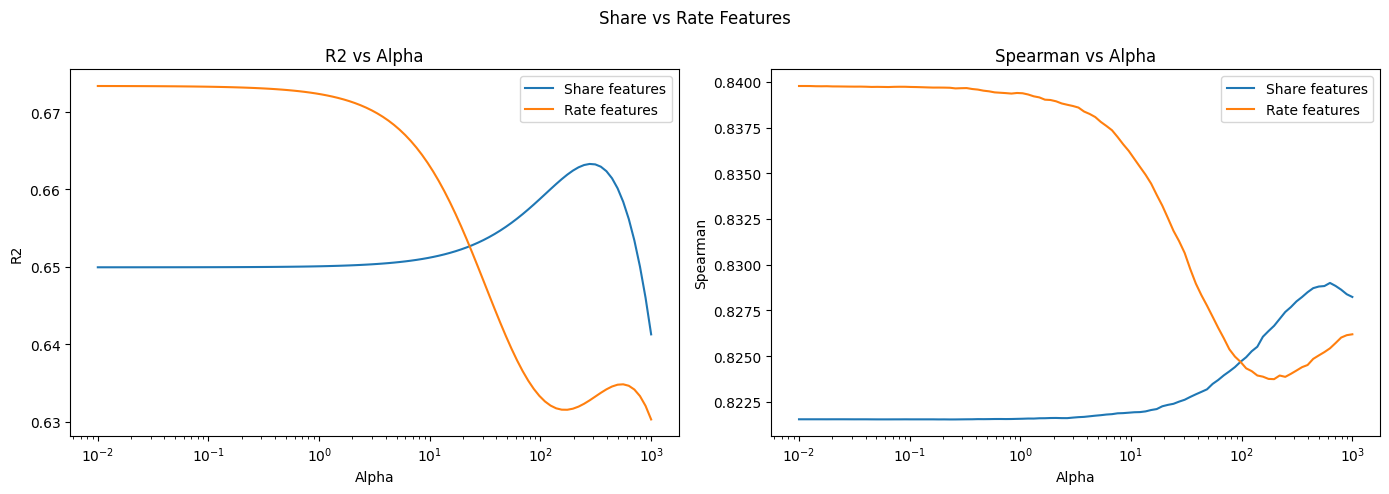

Share features - best R2: 0.6633 at alpha=278.2559, Spearman: 0.8277
Rate features  - best R2: 0.6734 at alpha=0.0100, Spearman: 0.8398


In [34]:
# create rate-based features for both years
def create_rate_features(raw: pl.DataFrame) -> pl.DataFrame:
    return raw.with_columns(
        (pl.col("total_crimes") / pl.col("lsoa_population") * 1000).alias("crime_rate_per_1000"),
        (pl.col("violent-crime") / pl.col("lsoa_population") * 1000).alias("violent_crime_rate"),
        (pl.col("burglary") / pl.col("lsoa_population") * 1000).alias("burglary_rate"),
        (pl.col("drugs") / pl.col("lsoa_population") * 1000).alias("drugs_rate"),
        (pl.col("total_claims") / pl.col("working_age_population")).alias("uc_claim_rate"),
        (pl.col("total_nwr_claims") / pl.col("working_age_population")).alias("uc_nwr_rate"),
        (pl.col("total_transactions") / pl.col("lsoa_population") * 1000).alias("transactions_per_capita"),
        (pl.col("aged_under_15") / pl.col("lsoa_population")).alias("youth_share"),
        (pl.col("pension_age_population") / pl.col("lsoa_population")).alias("elderly_share"),
    )

rate_2019 = create_rate_features(df_2019).with_columns(pl.lit("2019-09-01").alias("snapshot_date"))
rate_2025 = create_rate_features(anchor_dfs.get("2025")).with_columns(pl.lit("2025-10-01").alias("snapshot_date"))
rate_combined = pl.concat([rate_2019, rate_2025], how="diagonal_relaxed")

rate_input_path = project_root / "data" / "input" / "combined_rate_features_test.parquet"
rate_combined.write_parquet(rate_input_path)

# config
rate_config = FeatureSetConfig(
    name="rate_features_test",
    description="Rate-based features for comparison against share-based design",
    groups={
        "index": GroupConfig(columns=["snapshot_date"]),
        "crime": GroupConfig(columns=[
            "crime_rate_per_1000",
            "violent_crime_rate",
            "burglary_rate",
            "drugs_rate",
            "resolution_rate",
        ]),
        "uc": GroupConfig(columns=[
            "uc_claim_rate",
            "uc_nwr_rate",
            "%_claims_planfw",
            "%_claims_sfw",
        ]),
        "land_registry": GroupConfig(columns=[
            "lsoa_mean_price",
            "lsoa_median_price",
            "lsoa_price_inequality",
            "transactions_per_capita",
            "flats_proportion",
            "terraced_proportion",
            "detached_proportion",
            "freehold_proportion",
        ]),
        "osm_landuse": GroupConfig(columns=[
            "landuse_residential_0",
            "landuse_industrial_0",
            "landuse_commercial_0",
            "streetlit_percentage",
        ]),
        "demographics": GroupConfig(columns=[
            "youth_share",
            "elderly_share",
        ]),
    },
)

rate_features_df, *_ = create_feature_set(rate_input_path, rate_config)

target_z = prepare_target_zscore(df_targets_2019, df_targets_2025)
pooled_rates = rate_features_df.join(target_z, on=["lsoa_code", "snapshot_date"], how="inner")

feature_cols_rates = [c for c in rate_features_df.columns if c not in ("lsoa_code", "snapshot_date")]
X_rates = StandardScaler().fit_transform(pooled_rates.select(feature_cols_rates).to_numpy())
y_rates = pooled_rates.select("target").to_numpy().ravel()

_, groups_rates, _ = fetch_spatial_support_data(
    lsoa_codes=pooled_rates.select("lsoa_code").to_series().to_list(),
    boundaries_path=paths.polygons,
    lookup_path=paths.lads,
    n_clusters_per_city=8,
)

results_rates = []
for alpha in alphas:
    result = cross_validate(X_rates, y_rates, model=Ridge(alpha=alpha), cv_splitter=GroupKFold(n_splits=5), groups=groups_rates)
    result["alpha"] = alpha
    results_rates.append(result)

results_rates_df = pl.DataFrame(results_rates)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(results_df["alpha"], results_df["r2_mean"], label="Share features")
axes[0].plot(results_rates_df["alpha"], results_rates_df["r2_mean"], label="Rate features")
axes[0].set_xscale("log")
axes[0].set_xlabel("Alpha")
axes[0].set_ylabel("R2")
axes[0].set_title("R2 vs Alpha")
axes[0].legend()

axes[1].plot(results_df["alpha"], results_df["spearman_mean"], label="Share features")
axes[1].plot(results_rates_df["alpha"], results_rates_df["spearman_mean"], label="Rate features")
axes[1].set_xscale("log")
axes[1].set_xlabel("Alpha")
axes[1].set_ylabel("Spearman")
axes[1].set_title("Spearman vs Alpha")
axes[1].legend()

fig.suptitle("Share vs Rate Features")
fig.tight_layout()
plt.show()

best_share = results_df.row(results_df["r2_mean"].arg_max(), named=True)
best_rate = results_rates_df.row(results_rates_df["r2_mean"].arg_max(), named=True)
print(f"Share features - best R2: {best_share['r2_mean']:.4f} at alpha={best_share['alpha']:.4f}, Spearman: {best_share['spearman_mean']:.4f}")
print(f"Rate features  - best R2: {best_rate['r2_mean']:.4f} at alpha={best_rate['alpha']:.4f}, Spearman: {best_rate['spearman_mean']:.4f}")

rate config is actually slightly betterr than the share config, at low alphas, then colapses quickly when regularisation kicks in. 

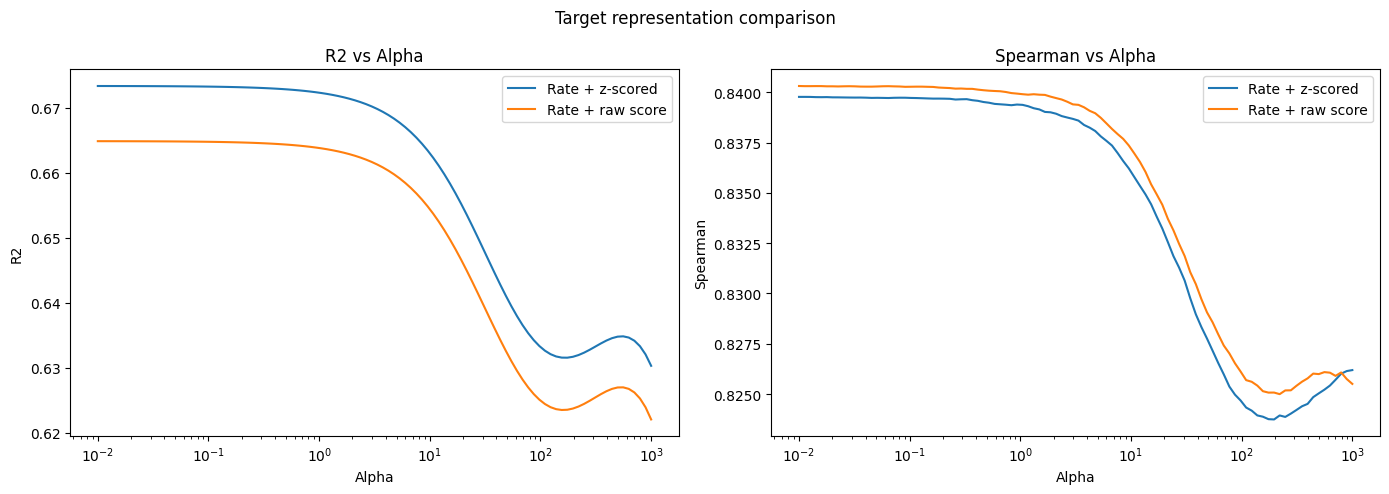

Rate + z-scored - best R2: 0.6734 at alpha=0.0100
Rate + raw score - best R2: 0.6649 at alpha=0.0100


In [35]:
pooled_raw = rate_features_df.join(df_tgt_raw_scores, on=["lsoa_code", "snapshot_date"], how="inner")

X_raw = StandardScaler().fit_transform(pooled_raw.select(feature_cols_rates).to_numpy())
y_raw = pooled_raw.select("target").to_numpy().ravel()

results_raw = []
for alpha in alphas:
    result = cross_validate(X_raw, y_raw, model=Ridge(alpha=alpha), cv_splitter=GroupKFold(n_splits=5), groups=groups_rates)
    result["alpha"] = alpha
    results_raw.append(result)

results_raw_df = pl.DataFrame(results_raw)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(results_rates_df["alpha"], results_rates_df["r2_mean"], label="Rate + z-scored")
axes[0].plot(results_raw_df["alpha"], results_raw_df["r2_mean"], label="Rate + raw score")
axes[0].set_xscale("log")
axes[0].set_xlabel("Alpha")
axes[0].set_ylabel("R2")
axes[0].set_title("R2 vs Alpha")
axes[0].legend()

axes[1].plot(results_rates_df["alpha"], results_rates_df["spearman_mean"], label="Rate + z-scored")
axes[1].plot(results_raw_df["alpha"], results_raw_df["spearman_mean"], label="Rate + raw score")
axes[1].set_xscale("log")
axes[1].set_xlabel("Alpha")
axes[1].set_ylabel("Spearman")
axes[1].set_title("Spearman vs Alpha")
axes[1].legend()

fig.suptitle("Target representation comparison")
fig.tight_layout()
plt.show()

best_raw = results_raw_df.row(results_raw_df["r2_mean"].arg_max(), named=True)
best_z = results_rates_df.row(results_rates_df["r2_mean"].arg_max(), named=True)
print(f"Rate + z-scored - best R2: {best_z['r2_mean']:.4f} at alpha={best_z['alpha']:.4f}")
print(f"Rate + raw score - best R2: {best_raw['r2_mean']:.4f} at alpha={best_raw['alpha']:.4f}")

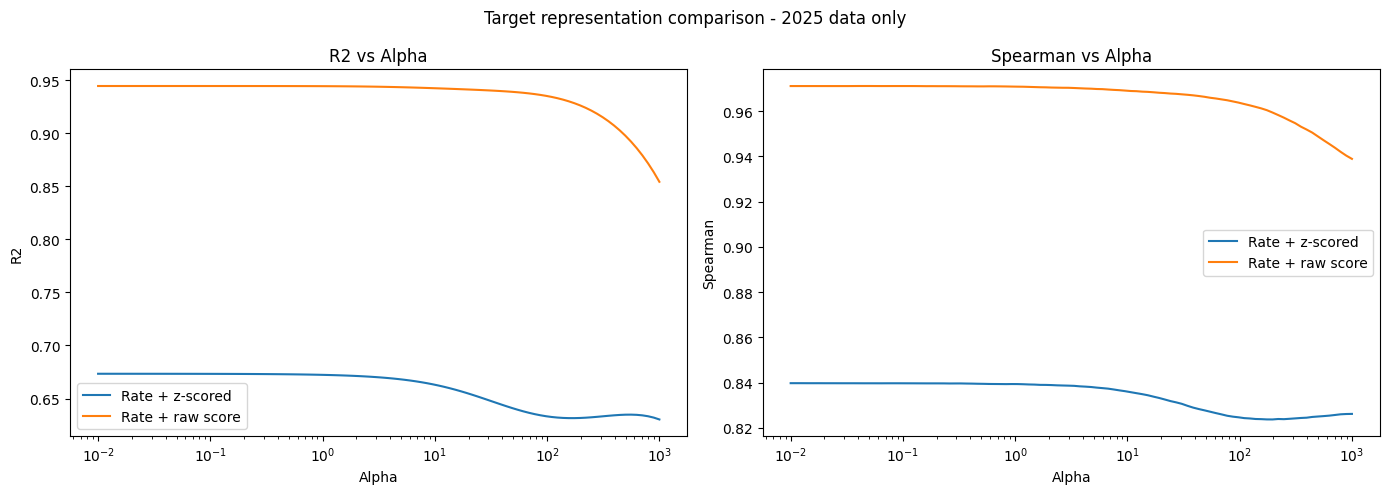

Rate + z-scored - best R2: 0.6734 at alpha=0.0100
Rate + raw score - best R2: 0.9445 at alpha=0.0100


In [36]:
df_rates_2025 = rate_features_df.filter(pl.col("snapshot_date").eq("2025-10-01"))
raw_2025 = df_rates_2025.join(df_tgt_raw_scores, on=["lsoa_code", "snapshot_date"], how="inner")

X_2025 = StandardScaler().fit_transform(raw_2025.select(feature_cols_rates).to_numpy())
y_2025 = raw_2025.select("target").to_numpy().ravel()

_, groups_2025, _ = fetch_spatial_support_data(
    lsoa_codes=raw_2025.select("lsoa_code").to_series().to_list(),
    boundaries_path=paths.polygons,
    lookup_path=paths.lads,
    n_clusters_per_city=8,
)

results_raw = []
for alpha in alphas:
    result = cross_validate(X_2025, y_2025, model=Ridge(alpha=alpha), cv_splitter=GroupKFold(n_splits=5), groups=groups_2025)
    result["alpha"] = alpha
    results_raw.append(result)

results_raw_df = pl.DataFrame(results_raw)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(results_rates_df["alpha"], results_rates_df["r2_mean"], label="Rate + z-scored")
axes[0].plot(results_raw_df["alpha"], results_raw_df["r2_mean"], label="Rate + raw score")
axes[0].set_xscale("log")
axes[0].set_xlabel("Alpha")
axes[0].set_ylabel("R2")
axes[0].set_title("R2 vs Alpha")
axes[0].legend()

axes[1].plot(results_rates_df["alpha"], results_rates_df["spearman_mean"], label="Rate + z-scored")
axes[1].plot(results_raw_df["alpha"], results_raw_df["spearman_mean"], label="Rate + raw score")
axes[1].set_xscale("log")
axes[1].set_xlabel("Alpha")
axes[1].set_ylabel("Spearman")
axes[1].set_title("Spearman vs Alpha")
axes[1].legend()

fig.suptitle("Target representation comparison - 2025 data only")
fig.tight_layout()
plt.show()

best_raw = results_raw_df.row(results_raw_df["r2_mean"].arg_max(), named=True)
best_z = results_rates_df.row(results_rates_df["r2_mean"].arg_max(), named=True)
print(f"Rate + z-scored - best R2: {best_z['r2_mean']:.4f} at alpha={best_z['alpha']:.4f}")
print(f"Rate + raw score - best R2: {best_raw['r2_mean']:.4f} at alpha={best_raw['alpha']:.4f}")

over the last few cells i have been investigating what causes the decreased performance from the previous notebooks to this one - the selection of features, the treatment of features, or the data.

Ive found that its combining the two timeframes that causes a drop in performance. This indicates strongly that the relationship between features and target changes over time. 

This points to two possible next steps:

    - train two models, one for 2019, one for 2025. Use both to interpolate. Then, for each quarter, take a weighted average of the two scores, using the distance from each point as the weight.
    - try and find features that are more consistent across the timeframes

Finding new features is i think interesting but not feasible in the timeframe. I already have the 2025 model (above)

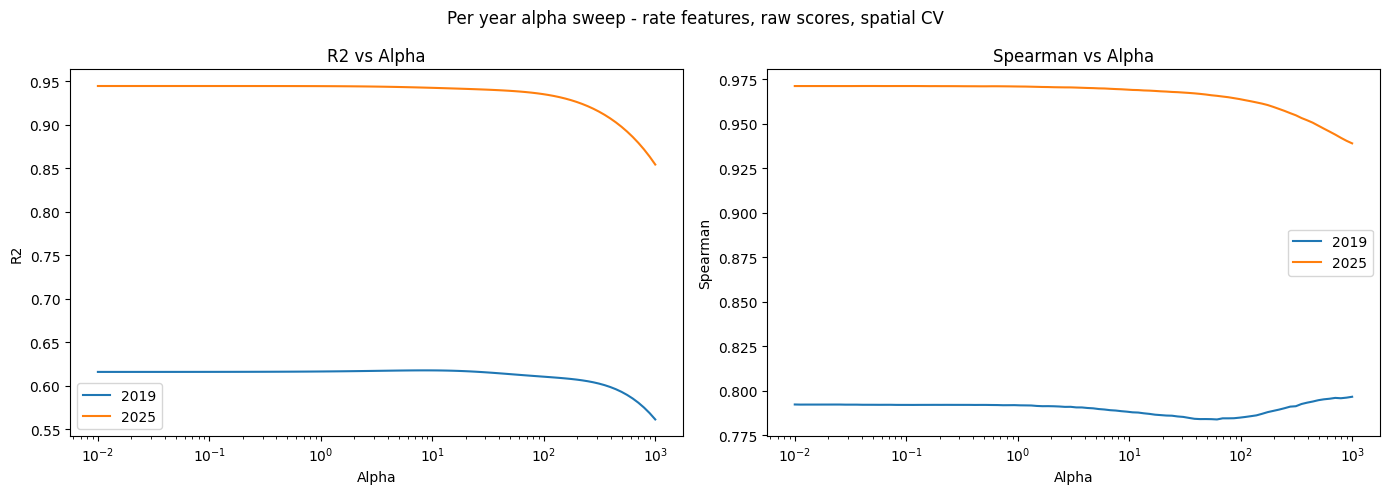

2019 - best R2: 0.6177 at alpha=8.4975, Spearman: 0.7885
2025 - best R2: 0.9445 at alpha=0.0100, Spearman: 0.9711


In [37]:
df_rates_2019 = rate_features_df.filter(pl.col("snapshot_date").eq("2019-09-01"))
raw_2019 = df_rates_2019.join(df_tgt_raw_scores, on=["lsoa_code", "snapshot_date"], how="inner")

X_2019 = StandardScaler().fit_transform(raw_2019.select(feature_cols_rates).to_numpy())
y_2019 = raw_2019.select("target").to_numpy().ravel()

_, groups_2019, _ = fetch_spatial_support_data(
    lsoa_codes=raw_2019.select("lsoa_code").to_series().to_list(),
    boundaries_path=paths.polygons,
    lookup_path=paths.lads,
    n_clusters_per_city=8,
)

results_2019 = []
for alpha in alphas:
    result = cross_validate(X_2019, y_2019, model=Ridge(alpha=alpha), cv_splitter=GroupKFold(n_splits=5), groups=groups_2019)
    result["alpha"] = alpha
    results_2019.append(result)

results_2019_df = pl.DataFrame(results_2019)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(results_2019_df["alpha"], results_2019_df["r2_mean"], label="2019")
axes[0].plot(results_raw_df["alpha"], results_raw_df["r2_mean"], label="2025")
axes[0].set_xscale("log")
axes[0].set_xlabel("Alpha")
axes[0].set_ylabel("R2")
axes[0].set_title("R2 vs Alpha")
axes[0].legend()

axes[1].plot(results_2019_df["alpha"], results_2019_df["spearman_mean"], label="2019")
axes[1].plot(results_raw_df["alpha"], results_raw_df["spearman_mean"], label="2025")
axes[1].set_xscale("log")
axes[1].set_xlabel("Alpha")
axes[1].set_ylabel("Spearman")
axes[1].set_title("Spearman vs Alpha")
axes[1].legend()

fig.suptitle("Per year alpha sweep - rate features, raw scores, spatial CV")
fig.tight_layout()
plt.show()

best_2019 = results_2019_df.row(results_2019_df["r2_mean"].arg_max(), named=True)
best_2025 = results_raw_df.row(results_raw_df["r2_mean"].arg_max(), named=True)
print(f"2019 - best R2: {best_2019['r2_mean']:.4f} at alpha={best_2019['alpha']:.4f}, Spearman: {best_2019['spearman_mean']:.4f}")
print(f"2025 - best R2: {best_2025['r2_mean']:.4f} at alpha={best_2025['alpha']:.4f}, Spearman: {best_2025['spearman_mean']:.4f}")

2019 performs significantly worse than 2025. i suspect the reason is universal credit. We know that it is the strongest predictor in 2025, and was still rolling out in 2019. All of our research so far has focused on finding the best model for right now (using 2025 ground truth). There is probably anothe feature set that is optimal for 2019. 

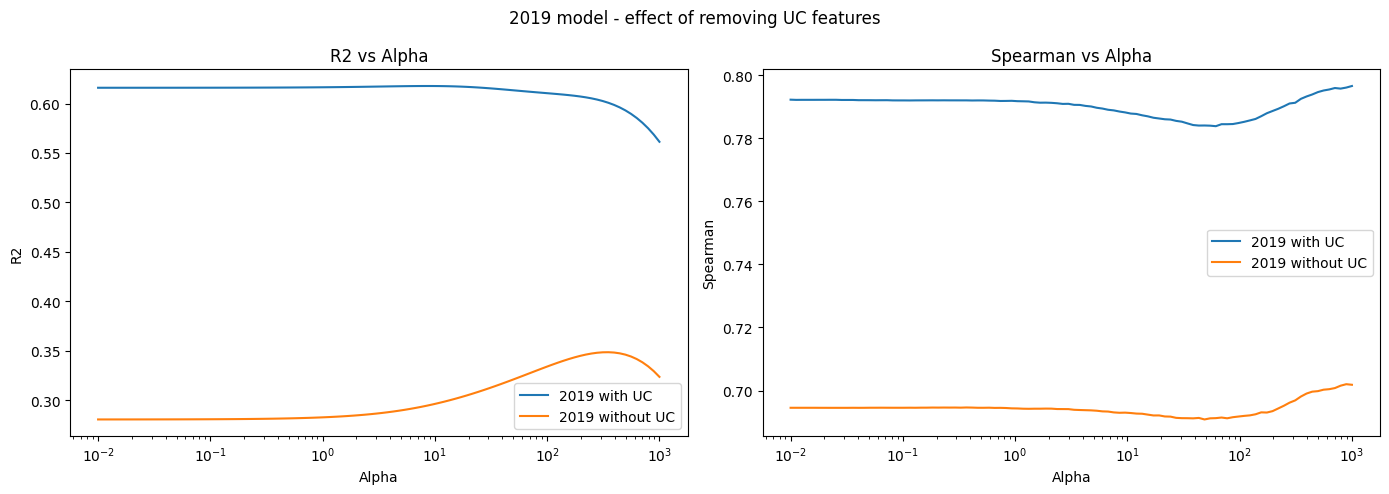

2019 with UC    - best R2: 0.6177 at alpha=8.4975, Spearman: 0.7885
2019 without UC - best R2: 0.3485 at alpha=351.1192, Spearman: 0.6981


In [38]:
config_2019_no_uc = FeatureSetConfig(
    name="rate_features_2019_no_uc",
    description="2019-optimised config - no UC features due to incomplete rollout",
    groups={
        "index": GroupConfig(columns=["snapshot_date"]),
        "crime": GroupConfig(columns=[
            "crime_rate_per_1000",
            "violent_crime_rate",
            "burglary_rate",
            "drugs_rate",
            "resolution_rate",
        ]),
        "land_registry": GroupConfig(columns=[
            "lsoa_mean_price",
            "lsoa_median_price",
            "lsoa_price_inequality",
            "transactions_per_capita",
            "flats_proportion",
            "terraced_proportion",
            "detached_proportion",
            "freehold_proportion",
        ]),
        "osm_landuse": GroupConfig(columns=[
            "landuse_residential_0",
            "landuse_industrial_0",
            "landuse_commercial_0",
            "streetlit_percentage",
        ]),
        "demographics": GroupConfig(columns=[
            "youth_share",
            "elderly_share",
        ]),
    },
)

features_2019_no_uc, *_ = create_feature_set(rate_input_path, config_2019_no_uc)
features_2019_no_uc = features_2019_no_uc.filter(pl.col("snapshot_date").eq("2019-09-01"))
joined_2019_no_uc = features_2019_no_uc.join(df_tgt_raw_scores, on=["lsoa_code", "snapshot_date"], how="inner")

feature_cols_no_uc = [c for c in features_2019_no_uc.columns if c not in ("lsoa_code", "snapshot_date")]
X_2019_no_uc = StandardScaler().fit_transform(joined_2019_no_uc.select(feature_cols_no_uc).to_numpy())
y_2019_no_uc = joined_2019_no_uc.select("target").to_numpy().ravel()

_, groups_2019_no_uc, _ = fetch_spatial_support_data(
    lsoa_codes=joined_2019_no_uc.select("lsoa_code").to_series().to_list(),
    boundaries_path=paths.polygons,
    lookup_path=paths.lads,
    n_clusters_per_city=8,
)

results_2019_no_uc = []
for alpha in alphas:
    result = cross_validate(X_2019_no_uc, y_2019_no_uc, model=Ridge(alpha=alpha), cv_splitter=GroupKFold(n_splits=5), groups=groups_2019_no_uc)
    result["alpha"] = alpha
    results_2019_no_uc.append(result)

results_2019_no_uc_df = pl.DataFrame(results_2019_no_uc)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(results_2019_df["alpha"], results_2019_df["r2_mean"], label="2019 with UC")
axes[0].plot(results_2019_no_uc_df["alpha"], results_2019_no_uc_df["r2_mean"], label="2019 without UC")
axes[0].set_xscale("log")
axes[0].set_xlabel("Alpha")
axes[0].set_ylabel("R2")
axes[0].set_title("R2 vs Alpha")
axes[0].legend()

axes[1].plot(results_2019_df["alpha"], results_2019_df["spearman_mean"], label="2019 with UC")
axes[1].plot(results_2019_no_uc_df["alpha"], results_2019_no_uc_df["spearman_mean"], label="2019 without UC")
axes[1].set_xscale("log")
axes[1].set_xlabel("Alpha")
axes[1].set_ylabel("Spearman")
axes[1].set_title("Spearman vs Alpha")
axes[1].legend()

fig.suptitle("2019 model - effect of removing UC features")
fig.tight_layout()
plt.show()

best_with_uc = results_2019_df.row(results_2019_df["r2_mean"].arg_max(), named=True)
best_no_uc = results_2019_no_uc_df.row(results_2019_no_uc_df["r2_mean"].arg_max(), named=True)
print(f"2019 with UC    - best R2: {best_with_uc['r2_mean']:.4f} at alpha={best_with_uc['alpha']:.4f}, Spearman: {best_with_uc['spearman_mean']:.4f}")
print(f"2019 without UC - best R2: {best_no_uc['r2_mean']:.4f} at alpha={best_no_uc['alpha']:.4f}, Spearman: {best_no_uc['spearman_mean']:.4f}")

lol so much worse

The chosen direction is to train separate models for 2019 and 2025, and then create a weighted average of the two predictions to interpolate between the two dates. This essentially just creates another linear equation, since its just a linear transform of two linear models. 
Its going to look something like:

$$
I = \frac{ w_{2019} * \hat{Y}_{2019} + w_{2025} * \hat{Y}_{2025} }{2}
$$

where $w_{2019}, w_{2025}$ are the weights assosiated with the distance from each anchor point, and $\hat{Y}$ is the predicted score of a model, with each model being a linear regression:

$$
\hat{Y} = \theta  X + \epsilon
$$

given this, the first step is to do some basic investigation into the best model to use for 2019. We can use lots of the learnings from the research already carried out in this project, but need to apply it to 2019 data specifically to make sure it holds. 

The first step is to compare feature design approaches

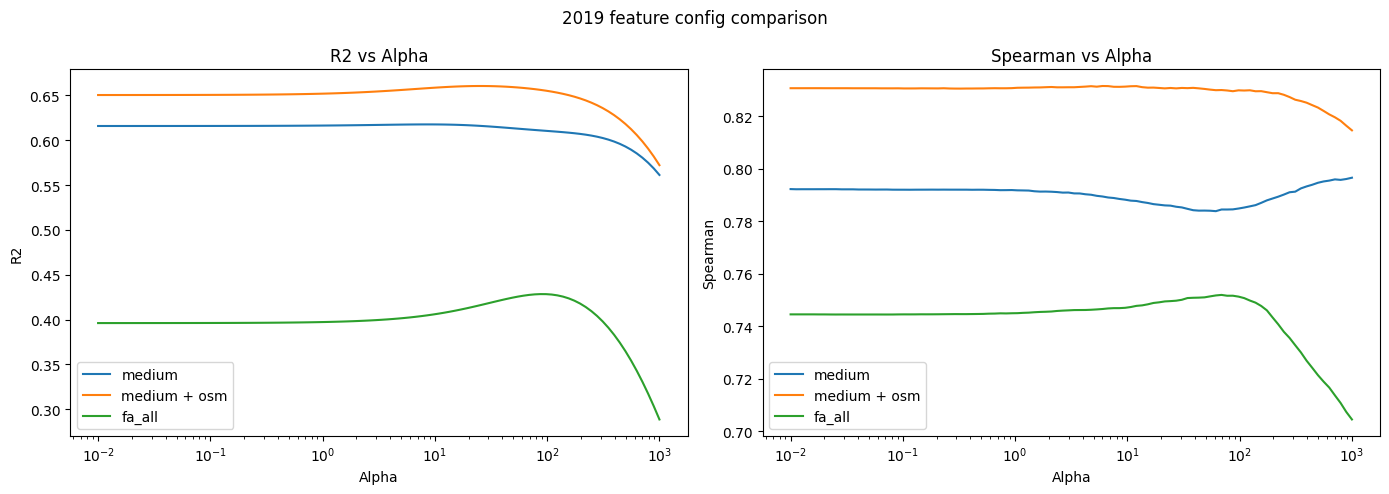

medium               - best R2: 0.6177 at alpha=8.4975, Spearman: 0.7885
medium + osm         - best R2: 0.6606 at alpha=24.2013, Spearman: 0.8308
fa_all               - best R2: 0.4284 at alpha=86.9749, Spearman: 0.7516


In [ ]:
from imd_features.config import ReductionMethod

# for config 1 i will use the medium rates - already exists as rate_config, already tested as results_2019_df

# for config 2 i will use medium + osm spatial features
config_medium_osm = FeatureSetConfig(
    name="rate_features_2019_osm",
    description="Medium rates plus OSM nearest distance and buffered counts",
    groups={
        "index": GroupConfig(columns=["snapshot_date"]),
        "crime": GroupConfig(columns=[
            "crime_rate_per_1000",
            "violent_crime_rate",
            "burglary_rate",
            "drugs_rate",
            "resolution_rate",
        ]),
        "uc": GroupConfig(columns=[
            "uc_claim_rate",
            "uc_nwr_rate",
            "%_claims_planfw",
            "%_claims_sfw",
        ]),
        "land_registry": GroupConfig(columns=[
            "lsoa_mean_price",
            "lsoa_median_price",
            "lsoa_price_inequality",
            "transactions_per_capita",
            "flats_proportion",
            "terraced_proportion",
            "detached_proportion",
            "freehold_proportion",
        ]),
        "osm_landuse": GroupConfig(columns=[
            "landuse_residential_0",
            "landuse_industrial_0",
            "landuse_commercial_0",
            "streetlit_percentage",
        ]),
        "osm_nearest": GroupConfig(columns=[
            "nearest_pharmacy",
            "nearest_hospital",
            "nearest_school",
            "nearest_kindergarten",
            "nearest_college",
            "nearest_university",
            "nearest_gambling",
        ]),
        "osm_counts": GroupConfig(columns=[
            "count_healthcare_access_500",
            "count_healthcare_access_1000",
            "count_education_skills_500",
            "count_education_skills_1000",
            "count_essential_services_500",
            "count_essential_services_1000",
            "count_fast_food_takeaway_500",
            "count_fast_food_takeaway_1000",
            "count_alcohol_gambling_500",
            "count_alcohol_gambling_1000",
        ]),
        "demographics": GroupConfig(columns=[
            "youth_share",
            "elderly_share",
        ]),
    },
)

# config 3, use all available features with FA reduction
all_cols = [c for c in rate_2019.columns if c not in ("lsoa_code", "snapshot_date")]
config_fa = FeatureSetConfig(
    name="rate_features_2019_fa",
    description="All available features reduced with factor analysis",
    groups={
        "index": GroupConfig(columns=["snapshot_date"]),
        "all": GroupConfig(
            columns=all_cols,
            scale=True,
            reduction_method=ReductionMethod.FA,
            n_components=15,
        ),
    },
)

configs_to_test = {
    "medium": (rate_config, results_2019_df),  # already have results
    "medium + osm": (config_medium_osm, None),
    "fa_all": (config_fa, None),
}

all_results = {"medium": results_2019_df}

for name, (config, existing) in configs_to_test.items():
    if existing is not None:
        continue

    feat_df, *_ = create_feature_set(rate_input_path, config)
    feat_2019 = feat_df.filter(pl.col("snapshot_date").eq("2019-09-01"))
    joined = feat_2019.join(df_tgt_raw_scores, on=["lsoa_code", "snapshot_date"], how="inner")

    feat_cols = [c for c in feat_2019.columns if c not in ("lsoa_code", "snapshot_date")]
    X = StandardScaler().fit_transform(joined.select(feat_cols).to_numpy())
    y = joined.select("target").to_numpy().ravel()

    _, groups, _ = fetch_spatial_support_data(
        lsoa_codes=joined.select("lsoa_code").to_series().to_list(),
        boundaries_path=paths.polygons,
        lookup_path=paths.lads,
        n_clusters_per_city=8,
    )

    results = []
    for alpha in alphas:
        result = cross_validate(X, y, model=Ridge(alpha=alpha), cv_splitter=GroupKFold(n_splits=5), groups=groups)
        result["alpha"] = alpha
        results.append(result)

    all_results[name] = pl.DataFrame(results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, rdf in all_results.items():
    axes[0].plot(rdf["alpha"], rdf["r2_mean"], label=name)
    axes[1].plot(rdf["alpha"], rdf["spearman_mean"], label=name)

axes[0].set_xscale("log")
axes[0].set_xlabel("Alpha")
axes[0].set_ylabel("R2")
axes[0].set_title("R2 vs Alpha")
axes[0].legend()

axes[1].set_xscale("log")
axes[1].set_xlabel("Alpha")
axes[1].set_ylabel("Spearman")
axes[1].set_title("Spearman vs Alpha")
axes[1].legend()

fig.suptitle("2019 feature config comparison")
fig.tight_layout()
plt.show()

for name, rdf in all_results.items():
    best = rdf.row(rdf["r2_mean"].arg_max(), named=True)
    print(f"{name:20s} - best R2: {best['r2_mean']:.4f} at alpha={best['alpha']:.4f}, Spearman: {best['spearman_mean']:.4f}")

the small but meaningfull improvement in performance metrics in r2 whith added features means that the model can stand to learn from extra signal provided by additional features. 

I think that this encouraging finding means it is worthwhile trying another variation. I will try including the same raw features present in medium+osm, and expand the land reg, crimes, or osm features included but use factor analysis per group to keep the number of dimensions similar. Key predictors that we have found to be important so far should be kept unreduced so that they stay interpretable. I will inspect the coefficients of the models first to help make this decision.


In [42]:
feat_osm, *_ = create_feature_set(rate_input_path, config_medium_osm)
feat_osm_2019 = feat_osm.filter(pl.col("snapshot_date").eq("2019-09-01"))
joined_osm = feat_osm_2019.join(df_tgt_raw_scores, on=["lsoa_code", "snapshot_date"], how="inner")

feat_cols_osm = [c for c in feat_osm_2019.columns if c not in ("lsoa_code", "snapshot_date")]
X_osm = StandardScaler().fit_transform(joined_osm.select(feat_cols_osm).to_numpy())
y_osm = joined_osm.select("target").to_numpy().ravel()

model_osm = Ridge(alpha=1.0)
model_osm.fit(X_osm, y_osm)

coefs = pl.DataFrame({
    "feature": feat_cols_osm,
    "coefficient": model_osm.coef_,
    "abs_coefficient": np.abs(model_osm.coef_),
}).sort("abs_coefficient", descending=True)


with pl.Config(tbl_rows=200):
    print(coefs)

shape: (40, 3)
┌───────────────────────────────┬─────────────┬─────────────────┐
│ feature                       ┆ coefficient ┆ abs_coefficient │
│ ---                           ┆ ---         ┆ ---             │
│ str                           ┆ f64         ┆ f64             │
╞═══════════════════════════════╪═════════════╪═════════════════╡
│ uc_claim_rate                 ┆ 14.819002   ┆ 14.819002       │
│ youth_share                   ┆ 4.585293    ┆ 4.585293        │
│ uc_nwr_rate                   ┆ -4.051652   ┆ 4.051652        │
│ nearest_gambling              ┆ -2.88785    ┆ 2.88785         │
│ violent_crime_rate            ┆ 2.8257      ┆ 2.8257          │
│ lsoa_median_price             ┆ -2.638792   ┆ 2.638792        │
│ nearest_hospital              ┆ 2.565912    ┆ 2.565912        │
│ detached_proportion           ┆ -2.53965    ┆ 2.53965         │
│ count_alcohol_gambling_1000   ┆ 2.474311    ┆ 2.474311        │
│ transactions_per_capita       ┆ -1.935813   ┆ 1.935813     

I'm going to create a group of features that are "key predictors", basically the ones that have the largest coefficients, except for the ones with a buffer distance that are obviously going to load well onto a single factor (definitly contain a lot of mutual information). Then, i can group the rest up into sensible groups and reduce them. In this way, i can keep the key predictors interpretable, but hopefully give the model more signal in fewer features.

In [43]:
config_hybrid_1 = FeatureSetConfig(
    name="rate_features_2019_hybrid",
    description="Strong predictors unreduced, weaker correlated groups FA reduced",
    groups={
        "index": GroupConfig(columns=["snapshot_date"]),
        "key_predictors": GroupConfig(columns=[
            "uc_claim_rate",
            "uc_nwr_rate",
            "youth_share",
            "elderly_share",
            "violent_crime_rate",
            "lsoa_median_price",
            "detached_proportion",
            "transactions_per_capita",
        ]),
        "crime_secondary": GroupConfig(
            columns=[
                "crime_rate_per_1000",
                "burglary_rate",
                "drugs_rate",
                "resolution_rate",
            ],
            scale=True,
            reduction_method=ReductionMethod.FA,
            n_components=2,
        ),
        "osm_accessibility": GroupConfig(
            columns=[
                "nearest_pharmacy",
                "nearest_hospital",
                "nearest_school",
                "nearest_kindergarten",
                "nearest_college",
                "nearest_university",
                "nearest_gambling",
                "count_healthcare_access_500",
                "count_healthcare_access_1000",
                "count_education_skills_500",
                "count_education_skills_1000",
                "count_essential_services_500",
                "count_essential_services_1000",
                "count_fast_food_takeaway_500",
                "count_fast_food_takeaway_1000",
                "count_alcohol_gambling_500",
                "count_alcohol_gambling_1000",
            ],
            scale=True,
            reduction_method=ReductionMethod.FA,
            n_components=4,
        ),
        "land_registry_secondary": GroupConfig(
            columns=[
                "lsoa_mean_price",
                "lsoa_price_inequality",
                "flats_proportion",
                "terraced_proportion",
                "freehold_proportion",
            ],
            scale=True,
            reduction_method=ReductionMethod.FA,
            n_components=2,
        ),
        "osm_landuse": GroupConfig(
            columns=[
                "landuse_residential_0",
                "landuse_industrial_0",
                "landuse_commercial_0",
                "streetlit_percentage",
            ],
            scale=True,
            reduction_method=ReductionMethod.FA,
            n_components=2,
        ),
        "uc_secondary": GroupConfig(
            columns=[
                "%_claims_planfw",
                "%_claims_sfw",
            ],
            scale=True,
            reduction_method=ReductionMethod.FA,
            n_components=1,
        ),
    },
)

im going to do two versions, the above then a slightly expanded version with the same groups and total number of features but more features included in each group. We can see if the model continues to learn from more signal being added or if the factor analysis starts to degrade.

In [44]:
config_hybrid_2 = FeatureSetConfig(
    name="rate_features_2019_hybrid_expanded",
    description="Hybrid config with expanded input features per FA group",
    groups={
        "index": GroupConfig(columns=["snapshot_date"]),
        "key_predictors": GroupConfig(columns=[
            "uc_claim_rate",
            "uc_nwr_rate",
            "youth_share",
            "elderly_share",
            "violent_crime_rate",
            "lsoa_median_price",
            "detached_proportion",
            "transactions_per_capita",
        ]),
        "crime_secondary": GroupConfig(
            columns=[
                "crime_rate_per_1000",
                "burglary_rate",
                "drugs_rate",
                "resolution_rate",
                "shoplifting",
                "robbery",
                "other-theft",
                "criminal-damage-arson",
                "public-order",
                "possession-of-weapons",
            ],
            scale=True,
            reduction_method=ReductionMethod.FA,
            n_components=2,
        ),
        "osm_accessibility": GroupConfig(
            columns=[
                "nearest_pharmacy",
                "nearest_hospital",
                "nearest_school",
                "nearest_kindergarten",
                "nearest_college",
                "nearest_university",
                "nearest_gambling",
                "nearest_theatre",
                "count_healthcare_access_500",
                "count_healthcare_access_1000",
                "count_healthcare_access_2000",
                "count_education_skills_500",
                "count_education_skills_1000",
                "count_education_skills_2000",
                "count_essential_services_500",
                "count_essential_services_1000",
                "count_essential_services_2000",
                "count_fast_food_takeaway_500",
                "count_fast_food_takeaway_1000",
                "count_fast_food_takeaway_2000",
                "count_alcohol_gambling_500",
                "count_alcohol_gambling_1000",
                "count_alcohol_gambling_2000",
            ],
            scale=True,
            reduction_method=ReductionMethod.FA,
            n_components=4,
        ),
        "land_registry_secondary": GroupConfig(
            columns=[
                "lsoa_mean_price",
                "lsoa_price_inequality",
                "flats_proportion",
                "terraced_proportion",
                "freehold_proportion",
                "new_build_price_premium",
                "lsoa_stdev_price",
            ],
            scale=True,
            reduction_method=ReductionMethod.FA,
            n_components=2,
        ),
        "osm_landuse": GroupConfig(
            columns=[
                "landuse_residential_0",
                "landuse_industrial_0",
                "landuse_commercial_0",
                "landuse_retail_0",
                "landuse_construction_0",
                "landuse_recreation_ground_0",
                "streetlit_percentage",
            ],
            scale=True,
            reduction_method=ReductionMethod.FA,
            n_components=2,
        ),
        "uc_secondary": GroupConfig(
            columns=[
                "%_claims_planfw",
                "%_claims_sfw",
                "%_claims_nwr",
                "%_claims_prepfw",
            ],
            scale=True,
            reduction_method=ReductionMethod.FA,
            n_components=1,
        ),
    },
)

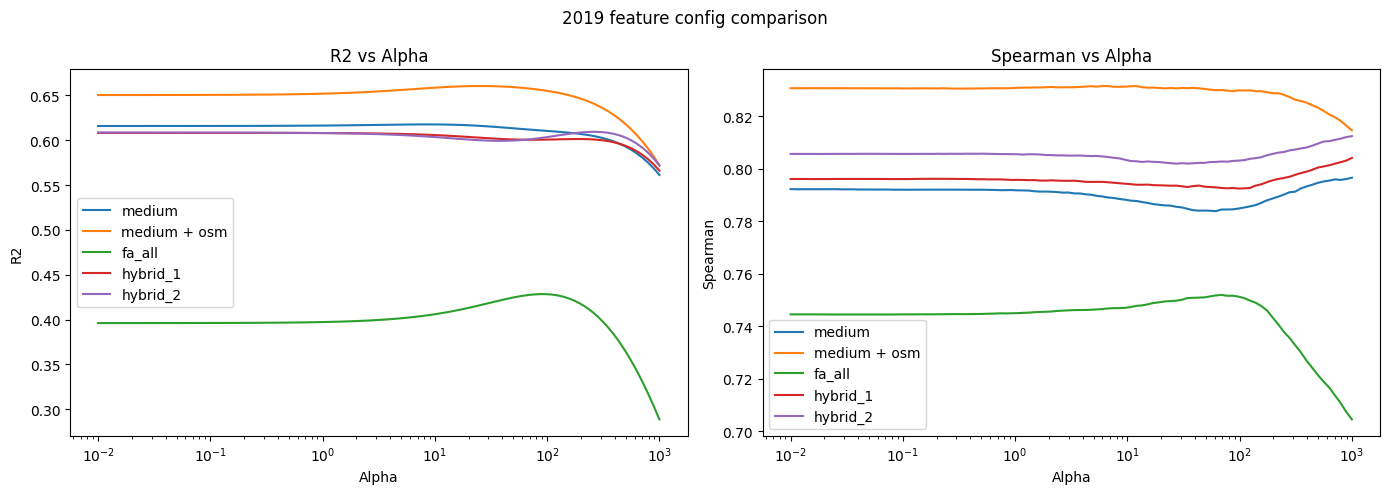

medium               - best R2: 0.6177 at alpha=8.4975, Spearman: 0.7885
medium + osm         - best R2: 0.6606 at alpha=24.2013, Spearman: 0.8308
fa_all               - best R2: 0.4284 at alpha=86.9749, Spearman: 0.7516
hybrid_1             - best R2: 0.6082 at alpha=0.0100, Spearman: 0.7961
hybrid_2             - best R2: 0.6094 at alpha=247.7076, Spearman: 0.8064


In [45]:
configs_to_test = {
    "medium": (rate_config, results_2019_df),  # already have results
    "medium + osm": (config_medium_osm, None),
    "fa_all": (config_fa, None),
    "hybrid_1": (config_hybrid_1, None),
    "hybrid_2": (config_hybrid_2, None),
}

all_results = {"medium": results_2019_df}

for name, (config, existing) in configs_to_test.items():
    if existing is not None:
        continue

    feat_df, *_ = create_feature_set(rate_input_path, config)
    feat_2019 = feat_df.filter(pl.col("snapshot_date").eq("2019-09-01"))
    joined = feat_2019.join(df_tgt_raw_scores, on=["lsoa_code", "snapshot_date"], how="inner")

    feat_cols = [c for c in feat_2019.columns if c not in ("lsoa_code", "snapshot_date")]
    X = StandardScaler().fit_transform(joined.select(feat_cols).to_numpy())
    y = joined.select("target").to_numpy().ravel()

    _, groups, _ = fetch_spatial_support_data(
        lsoa_codes=joined.select("lsoa_code").to_series().to_list(),
        boundaries_path=paths.polygons,
        lookup_path=paths.lads,
        n_clusters_per_city=8,
    )

    results = []
    for alpha in alphas:
        result = cross_validate(X, y, model=Ridge(alpha=alpha), cv_splitter=GroupKFold(n_splits=5), groups=groups)
        result["alpha"] = alpha
        results.append(result)

    all_results[name] = pl.DataFrame(results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, rdf in all_results.items():
    axes[0].plot(rdf["alpha"], rdf["r2_mean"], label=name)
    axes[1].plot(rdf["alpha"], rdf["spearman_mean"], label=name)

axes[0].set_xscale("log")
axes[0].set_xlabel("Alpha")
axes[0].set_ylabel("R2")
axes[0].set_title("R2 vs Alpha")
axes[0].legend()

axes[1].set_xscale("log")
axes[1].set_xlabel("Alpha")
axes[1].set_ylabel("Spearman")
axes[1].set_title("Spearman vs Alpha")
axes[1].legend()

fig.suptitle("2019 feature config comparison")
fig.tight_layout()
plt.show()

for name, rdf in all_results.items():
    best = rdf.row(rdf["r2_mean"].arg_max(), named=True)
    print(f"{name:20s} - best R2: {best['r2_mean']:.4f} at alpha={best['alpha']:.4f}, Spearman: {best['spearman_mean']:.4f}")

The spearmans continuing to rise at high alpha after the r2 has started colapsing is interesting. Possibly the high alpha basically pushes most of the params to 0 meaning that the prediction is made only with a couple of features - this might be better for getting the predictions in the right order but the actual score predictions are noiser or more likely systematically off in some direction. Interesting, but a moot point here because we can see that the best model is the one where r2 and spearman actually peak at the same time. 

I will do a final fine grid of alpha values arround the best known models before writing the production predictor, but first i want to check if the same feature set that we have found for 2019 also performs well for 2025. if we can use the same one for both it will simplify the code to implement the final predictor. 

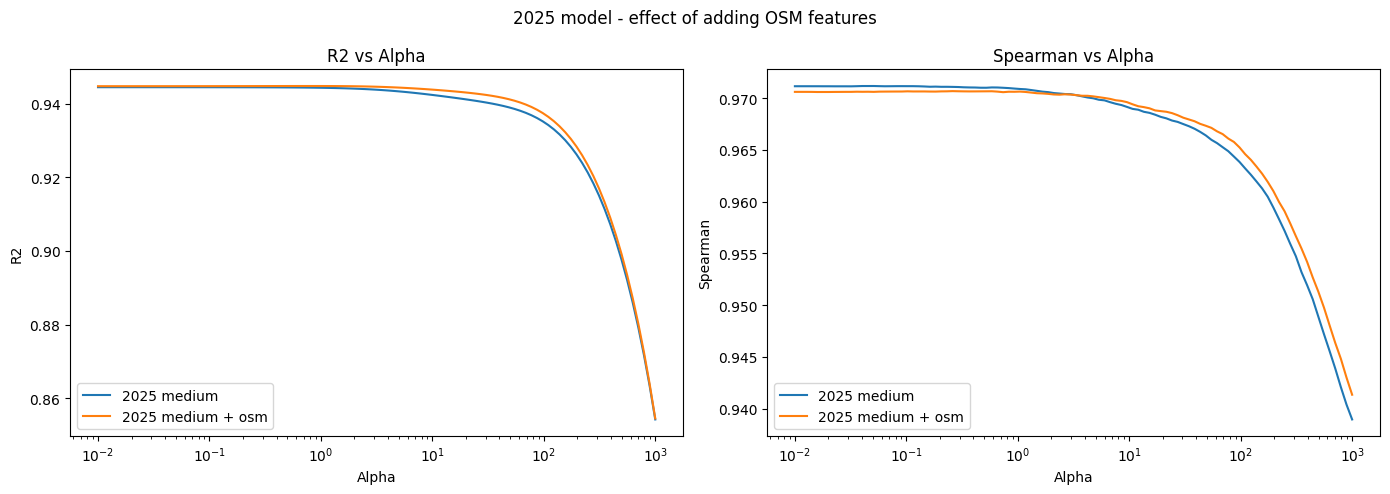

2025 medium     - best R2: 0.9445 at alpha=0.0100, Spearman: 0.9711
2025 medium+osm - best R2: 0.9448 at alpha=0.7391, Spearman: 0.9706


In [46]:
feat_osm_2025 = feat_osm.filter(pl.col("snapshot_date").eq("2025-10-01"))
joined_osm_2025 = feat_osm_2025.join(df_tgt_raw_scores, on=["lsoa_code", "snapshot_date"], how="inner")

feat_cols_osm = [c for c in feat_osm_2025.columns if c not in ("lsoa_code", "snapshot_date")]
X_osm_2025 = StandardScaler().fit_transform(joined_osm_2025.select(feat_cols_osm).to_numpy())
y_osm_2025 = joined_osm_2025.select("target").to_numpy().ravel()

_, groups_osm_2025, _ = fetch_spatial_support_data(
    lsoa_codes=joined_osm_2025.select("lsoa_code").to_series().to_list(),
    boundaries_path=paths.polygons,
    lookup_path=paths.lads,
    n_clusters_per_city=8,
)

results_osm_2025 = []
for alpha in alphas:
    result = cross_validate(X_osm_2025, y_osm_2025, model=Ridge(alpha=alpha), cv_splitter=GroupKFold(n_splits=5), groups=groups_osm_2025)
    result["alpha"] = alpha
    results_osm_2025.append(result)

results_osm_2025_df = pl.DataFrame(results_osm_2025)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(results_raw_df["alpha"], results_raw_df["r2_mean"], label="2025 medium")
axes[0].plot(results_osm_2025_df["alpha"], results_osm_2025_df["r2_mean"], label="2025 medium + osm")
axes[0].set_xscale("log")
axes[0].set_xlabel("Alpha")
axes[0].set_ylabel("R2")
axes[0].set_title("R2 vs Alpha")
axes[0].legend()

axes[1].plot(results_raw_df["alpha"], results_raw_df["spearman_mean"], label="2025 medium")
axes[1].plot(results_osm_2025_df["alpha"], results_osm_2025_df["spearman_mean"], label="2025 medium + osm")
axes[1].set_xscale("log")
axes[1].set_xlabel("Alpha")
axes[1].set_ylabel("Spearman")
axes[1].set_title("Spearman vs Alpha")
axes[1].legend()

fig.suptitle("2025 model - effect of adding OSM features")
fig.tight_layout()
plt.show()

best_med = results_raw_df.row(results_raw_df["r2_mean"].arg_max(), named=True)
best_osm = results_osm_2025_df.row(results_osm_2025_df["r2_mean"].arg_max(), named=True)
print(f"2025 medium     - best R2: {best_med['r2_mean']:.4f} at alpha={best_med['alpha']:.4f}, Spearman: {best_med['spearman_mean']:.4f}")
print(f"2025 medium+osm - best R2: {best_osm['r2_mean']:.4f} at alpha={best_osm['alpha']:.4f}, Spearman: {best_osm['spearman_mean']:.4f}")

These are basically the same scores - i think the model isn't stable enough that these difference aren't well within the sensitivity/confidence range of the cross validation.

Given that there is no provable performance difference, but the alpha clearly goes up with the added features, I would rather stick with the more interpretable, less regularised features of the original "medium config" rather than the expanded one. 

im moving onto a final, extremely fine alpha sweep with the best models. I doubt that the alpha will change much - especially not in a way that will generalise with new months etc, but worth doing just in case.

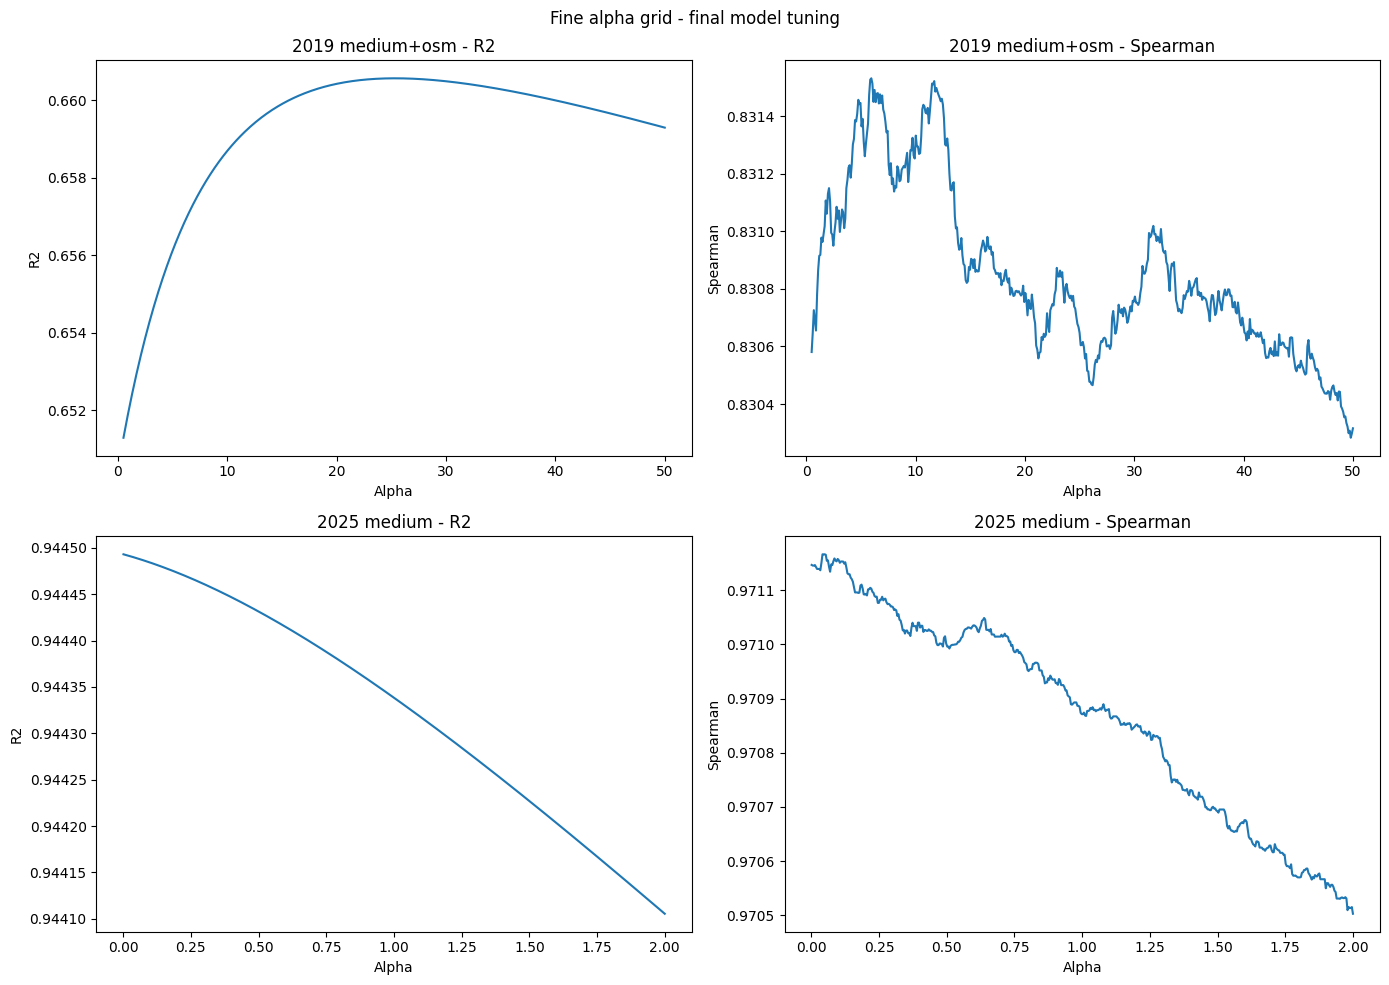

2019 - best R2: 0.660571 at alpha=25.2996, Spearman: 0.830616
2025 - best R2: 0.944493 at alpha=0.0010, Spearman: 0.971147


In [47]:
# fine alpha grids centred on the best values from previous runs, with very aggressive fine grid
alphas_2019_fine = np.linspace(0.5, 50, 500)
alphas_2025_fine = np.linspace(0.001, 2, 500)

# 2019 model using medium+osm feats
results_2019_fine = []
for alpha in alphas_2019_fine:
    result = cross_validate(X_osm, y_osm, model=Ridge(alpha=alpha), cv_splitter=GroupKFold(n_splits=5), groups=groups_2019)
    result["alpha"] = alpha
    results_2019_fine.append(result)

results_2019_fine_df = pl.DataFrame(results_2019_fine)

# 2025 model using medium w/o additional osm feats
results_2025_fine = []
for alpha in alphas_2025_fine:
    result = cross_validate(X_2025, y_2025, model=Ridge(alpha=alpha), cv_splitter=GroupKFold(n_splits=5), groups=groups_2025)
    result["alpha"] = alpha
    results_2025_fine.append(result)

results_2025_fine_df = pl.DataFrame(results_2025_fine)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(results_2019_fine_df["alpha"], results_2019_fine_df["r2_mean"])
axes[0, 0].set_xlabel("Alpha")
axes[0, 0].set_ylabel("R2")
axes[0, 0].set_title("2019 medium+osm - R2")

axes[0, 1].plot(results_2019_fine_df["alpha"], results_2019_fine_df["spearman_mean"])
axes[0, 1].set_xlabel("Alpha")
axes[0, 1].set_ylabel("Spearman")
axes[0, 1].set_title("2019 medium+osm - Spearman")

axes[1, 0].plot(results_2025_fine_df["alpha"], results_2025_fine_df["r2_mean"])
axes[1, 0].set_xlabel("Alpha")
axes[1, 0].set_ylabel("R2")
axes[1, 0].set_title("2025 medium - R2")

axes[1, 1].plot(results_2025_fine_df["alpha"], results_2025_fine_df["spearman_mean"])
axes[1, 1].set_xlabel("Alpha")
axes[1, 1].set_ylabel("Spearman")
axes[1, 1].set_title("2025 medium - Spearman")

fig.suptitle("Fine alpha grid - final model tuning")
fig.tight_layout()
plt.show()

best_2019 = results_2019_fine_df.row(results_2019_fine_df["r2_mean"].arg_max(), named=True)
best_2025 = results_2025_fine_df.row(results_2025_fine_df["r2_mean"].arg_max(), named=True)
print(f"2019 - best R2: {best_2019['r2_mean']:.6f} at alpha={best_2019['alpha']:.4f}, Spearman: {best_2019['spearman_mean']:.6f}")
print(f"2025 - best R2: {best_2025['r2_mean']:.6f} at alpha={best_2025['alpha']:.4f}, Spearman: {best_2025['spearman_mean']:.6f}")

two key observations here:

    1. in this graph, it seems that any l2 regularisation actually makes the r2 of the 2025 model worse. Its worth trying a vanilla linear regression predictor with no regularisation. It might be that we found a feature config that works well without any regularisation 
    2. the spearmans curve is so noisy because we are using error in score as the metric in the cost function (corresponds with r2), then just measuring the spearmans. It might be worth training models where the rank and score are both used to measure error. Especially since in 2019 the peak of spearmans doesn't correspond with the peak in r2. However, the absolute difference in spearmans is so small that this is probably unnecessary





checking linear regression w/o regularisation for 2025:

In [48]:
from sklearn.linear_model import LinearRegression

lr_result = cross_validate(X_2025, y_2025, model=LinearRegression(), cv_splitter=GroupKFold(n_splits=5), groups=groups_2025)

print(lr_result)

{'r2_mean': 0.9444932194663345, 'r2_std': 0.020834415836110547, 'r2_per_fold': [0.921037008843814, 0.9647414077544104, 0.918737497618367, 0.9669555371591496, 0.9509946459559309], 'rmse_mean': 3.806168004122161, 'rmse_std': 0.772628057272538, 'rmse_per_fold': [np.float64(3.274064356074103), np.float64(3.494614195410783), np.float64(5.2635877826396404), np.float64(3.117091865636019), np.float64(3.881481820850257)], 'spearman_mean': 0.9711465755377595, 'spearman_std': 0.011953283544668705, 'spearman_per_fold': [np.float64(0.9569285558672757), np.float64(0.9801780981060118), np.float64(0.9866902552266301), np.float64(0.9741972873865183), np.float64(0.9577386811023623)]}


This notebook has become much longer than expected with lots of new checks, tests, and experiments emerging. I will wrap up here and take the learnings into a new notebook to implement the final production predictor for interpolating quarter scores. The decisions that have been made are:

- final predictor will be an ensemble of two models, one optimised for 2019 and one for 2025, with a weighted average taken using the distance in time from each anchor for the quarter being predicted.
- 2025 will use a config of ~28 slected features
- 2019 will use a config of ~40 selected features (extra osm features compared to 2025)
- 2025 will be predicted using linear regression with no regularisation
- 2019 will be predicted using ridge regression with an alpha value of 25.3


